# Исследование маркетплейса

Автор: Вера Макухина  
Дата: февраль 2026

Быстрорастущий маркетплейс с комиссионной моделью монетизации (5% от суммы заказа).
Данные охватывают поведение пользователей, заказы и маркетинговые кампании.

Появилась задача оценить здоровье продукта: понять, где теряются пользователи,
что драйвит выручку и насколько эффективны каналы привлечения.

## О проекте

Данные собраны с помощью SQL в четыре таблицы: пользователи, события, заказы,
маркетинговые кампании. Таблица Campaign_costs предоставлена в готовом виде. Запросы по остальным доступны в файле [marketplace_data_preparation.sql](marketplace_data_preparation.sql).

Я исследовала поведение пользователей, рассчитала ключевые продуктовые
и бизнес-метрики, оценила юнит-экономику и нашла точки роста.

**Стек:** Python, pandas, numpy, scipy, matplotlib, SQL

## Структура анализа

1. Загрузка данных и предобработка
2. Верхнеуровневый анализ метрик
3. Юнит-экономика и монетизация
4. Сегментация, воронки и инсайты
5. A/B-тест: бонус на первую покупку для TikTok-пользователей

## Описание данных

**Users** — пользователи: id, дата регистрации, возраст, пол, регион,
канал привлечения, сегмент покупателя, когорта по неделе и месяцу.

**Events** — события: id события, id пользователя, дата, тип события,
ОС, устройство, товар (если применимо), неделя и месяц события.

**Orders** — заказы: id заказа, id пользователя, дата, товар, категория,
количество, цена за единицу, итоговая сумма, неделя и месяц заказа.

**Campaign_costs** — маркетинговые кампании: канал привлечения, месяц,
бюджет на канал.

Выручка маркетплейса считается как 5% от суммы заказа.  


## Цели анализа

- Оценить здоровье продукта через поведение пользователей и динамику продаж
- Найти узкие места в воронке покупок
- Выявить драйверы выручки
- Оценить эффективность маркетинговых каналов

## Метрики

**Здоровье продукта:** количество заказов, активность пользователей,
конверсия в покупку.

**Монетизация и юнит-экономика:** ARPU, AOV, CAC, ROI, LTV.

| Термин | Расшифровка |
|---|---|
| ARPU | Средняя выручка на одного пользователя |
| AOV | Средний чек |
| CAC | Стоимость привлечения одного пользователя |
| LTV | Прогнозируемая суммарная выручка от пользователя за всё время |
| ROI | Отдача на маркетинговый бюджет |
| Retention | Доля пользователей, вернувшихся через определённый период |

# Блок кода и расчета метрик

Загружу данные, проведу базовую предобработку. Проверю данные на дубликаты, пропуски; категориальные столбцы на опечатки и неточности. Даты приведу к формату дат. Проверю рамки исследуемого периода.

In [1]:
# Импорт библиотек
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy.stats import ttest_ind, mannwhitneyu

In [2]:
# Функция для построения столбчатых диаграмм с подписями для одной серии
def plot_bar_with_labels(df, x_col, y_col, title, ylabel, is_percent=False):
    plt.figure(figsize=(10, 5))
    bars = plt.bar(df[x_col], df[y_col])
    for bar, value in zip(bars, df[y_col]):
        label = f'{value * 100:.1f}%' if is_percent else f'{int(value)}'
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            label,
            ha='center',
            va='bottom'
        )
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(x_col)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


# Функция для подписей над столбцами для множественных графиков с группами
def add_labels(ax):
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                int(height),
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points'
            )


# Функция для расчёта и визуализации воронки по произвольному сегменту
def build_funnel(events_df, orders_df, steps, segment_col, segment_vals=None):
    """
    Строит heatmap классической конверсии воронки по любому сегменту.
    events_df    — таблица событий с колонкой segment_col
    orders_df    — таблица заказов с колонкой segment_col
    steps        — список шагов воронки (последний — 'purchase')
    segment_col  — название колонки сегмента
    segment_vals — список значений сегмента (если None — берёт все уникальные)
    """
    events_steps = steps[:-1]

    # Пользователи на шагах из Events
    events_funnel = (
        events_df[events_df['event_type'].isin(events_steps)]
        .groupby([segment_col, 'event_type'])['user_id']
        .nunique()
        .reset_index()
        .rename(columns={'event_type': 'step', 'user_id': 'users'})
    )

    # Пользователи с покупкой из Orders
    purchase_funnel = (
        orders_df
        .groupby(segment_col)['user_id']
        .nunique()
        .reset_index()
        .rename(columns={'user_id': 'users'})
    )
    purchase_funnel['step'] = 'purchase'

    funnel = pd.concat([events_funnel, purchase_funnel], ignore_index=True)

    # Упорядочиваю шаги
    funnel['step'] = pd.Categorical(funnel['step'], categories=steps, ordered=True)

    # Классическая конверсия от первого шага
    page_view_users = (
        funnel.query("step == 'page_view'")
        .set_index(segment_col)['users']
    )
    funnel['conversion'] = (
        funnel['users']
        / funnel[segment_col].map(page_view_users)
    )

    # Pivot для heatmap
    pivot = (
        funnel
        .pivot(index=segment_col, columns='step', values='conversion')
        .round(3)
    )

    plt.figure(figsize=(10, max(4, len(pivot) * 0.6 + 2)))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues')
    plt.title(f'Классическая воронка по {segment_col}')
    plt.xlabel('Шаг воронки')
    plt.ylabel(segment_col)
    plt.tight_layout()
    plt.show()

    return pivot


# Функция для расчёта месячных ARPU и ARPPU
def calc_arpu_arppu(orders_df, mau_df, paying_users_df):
    """
    Возвращает датафрейм с колонками: month, arpu, arppu.
    orders_df        — таблица заказов с колонками order_month, total_price
    mau_df           — датафрейм MAU: event_month, user_id (nunique)
    paying_users_df  — датафрейм уникальных покупателей: order_month, users_buy
    """
    total_sum = (
        orders_df
        .groupby('order_month')['total_price']
        .sum()
        .reset_index()
        .round()
    )

    # Мержу с MAU
    result = total_sum.merge(
        mau_df,
        left_on='order_month',
        right_on='event_month',
        how='inner'
    ).drop(columns='event_month')

    # Мержу с платящими пользователями
    result = result.merge(paying_users_df, on='order_month', how='inner')

    result['arpu'] = (result['total_price'] / result['user_id']).round()
    result['arppu'] = (result['total_price'] / result['users_buy']).round(2)

    return result[['order_month', 'arpu', 'arppu']]


In [3]:
# Загружаю данные

df_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv', 
                      parse_dates=['registration_date', 'cohort_week', 'cohort_month'])

df_events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv', 
                      parse_dates=['event_date', 'event_week', 'event_month'])

df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv', 
                      parse_dates=['order_date', 'order_week','order_month'])

df_camp = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv', 
                      parse_dates=['spend_month'])

In [4]:
# Смотрю основную информацию по каждому датасету
display(Markdown('**Пользователи**'))
df_users.info()
display(df_users.head(3))
display(Markdown("---"))

display(Markdown('**События**'))
df_events.info()
display(df_events.head(3))
display(Markdown("---"))

display(Markdown('**Заказы**'))
df_orders.info()
display(df_orders.head(3))
display(Markdown("---"))

display(Markdown('**Кампании**'))
df_camp.info()
display(df_camp.head(3))

**Пользователи**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01


---

**События**

...

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01


---

**Кампании**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB


,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750


В таблице с пользователями 44151 строки, 9 столбцов. Пропусков нет. Типы данных корректны.

В таблице с событиями 785859 строк, 9 столбцов. Пропуски есть в столбце 'product_name'. Вероятнее всего, не на все события существуют продукты и это нормально. Типы данных корректны.

В таблице с заказами 31357 строк, 10 столбцов. Пропусков нет. Типы данных корректны.

В таблице с кампаниями 88 строк, 4 столбца. Пропусков нет. Типы данных корректны.

-----

Дальше проверяю данные на дубликаты.

In [5]:
# Явные дубликаты
duplicates_users = df_users.duplicated().sum()
print(f'Количество дубликатов в табл. пользователей: {duplicates_users}')

duplicates_events = df_events.duplicated().sum()
print(f'Количество дубликатов в табл. событий: {duplicates_events}')

duplicates_orders = df_orders.duplicated().sum()
print(f'Количество дубликатов в табл. заказов: {duplicates_orders}')

duplicates_campaign_costs = df_camp.duplicated().sum()
print(f'Количество дубликатов в табл. кампаний: {duplicates_campaign_costs}')
display(Markdown("---"))

# Неявные дубликаты
duplicates_users_h = df_users.duplicated(subset=['user_id','registration_date','acq_channel'],keep=False).sum()
print(f'Количество строк с неявными дубликатами в табл. пользователей: {duplicates_users_h}')

duplicates_events_h = df_events.duplicated(subset=['user_id','event_id','event_type'],keep=False).sum()
print(f'Количество строк с неявными дубликатами в табл. событий: {duplicates_events_h}')

duplicates_orders_h = df_orders.duplicated(subset=['user_id','order_id','order_date'],keep=False).sum()
print(f'Количество строк с неявными дубликатами в табл. заказов: {duplicates_orders_h}')

duplicates_campaign_costs_h = df_camp.duplicated(subset=['acq_channel','spend_month','budget'],keep=False).sum()
print(f'Количество строк с неявными дубликатами в табл. кампаний: {duplicates_campaign_costs_h}')

Количество дубликатов в табл. пользователей: 0
Количество дубликатов в табл. событий: 0
Количество дубликатов в табл. заказов: 0
Количество дубликатов в табл. кампаний: 0


---

Количество строк с неявными дубликатами в табл. пользователей: 0
Количество строк с неявными дубликатами в табл. событий: 0
Количество строк с неявными дубликатами в табл. заказов: 0
Количество строк с неявными дубликатами в табл. кампаний: 0


Дубликатов нет, проверяю категориальные данные.

In [6]:
gender =  df_users['gender'].unique()
display(Markdown(f'**Пол пользователя**: {gender}'))

region =  df_users['region'].unique()
display(Markdown(f'**Регионы**: {region}'))

acq_channel =  df_users['acq_channel'].unique()
display(Markdown(f'**Каналы откуда пришли пользователи**: {acq_channel}'))

buyer_segment =  df_users['buyer_segment'].unique()
display(Markdown(f'**Сегменты покупателей**: {buyer_segment}'))

event_type =  df_events['event_type'].unique()
display(Markdown(f'**Типы событий**: {event_type}'))

os =  df_events['os'].unique()
display(Markdown(f'**Типы ОС**: {os}'))

device =  df_events['device'].unique()
display(Markdown(f'**Типы девайсов**: {device}'))

category_name =  df_orders['category_name'].unique()
display(Markdown(f'**Название категории товара**: {category_name}'))

acq_channel = df_camp['acq_channel'].unique()
display(Markdown(f'**Каналы кампаний**: {acq_channel}'))

**Пол пользователя**: ['M' 'F']

**Регионы**: ['Москва' 'Санкт-Петербург' 'Краснодар' 'Другие регионы' 'Нижний Новгород'
 'Екатеринбург' 'Московская область' 'Новосибирск' 'Ростов-на-Дону']

**Каналы откуда пришли пользователи**: ['Google Ads' 'Email Marketing' 'Affiliate' 'SEO' 'Social Media' 'TikTok']

**Сегменты покупателей**: ['regular' 'rare' 'one_time' 'medium']

**Типы событий**: ['page_view' 'product_view' 'product_click' 'add_to_cart' 'checkout_start'
 'checkout_complete' 'user_logout' 'search' 'category_view' 'filter_apply'
 'promo_view' 'wishlist_add' 'user_login' 'banner_click'
 'remove_from_cart']

**Типы ОС**: ['iOS' 'Windows' 'macOS' 'Android']

**Типы девайсов**: ['mobile' 'desktop' 'tablet']

**Название категории товара**: ['Инструменты и садовый инвентарь' 'Продукты питания' 'Женская одежда'
 'Аксессуары для гаджетов' 'Одежда для спорта' 'Декор и освещение'
 'Детская одежда' 'Детские игрушки' 'Книги и канцтовары'
 'Медицинские товары' 'Косметика и парфюмерия' 'Товары для туризма'
 'Сумки и аксессуары' 'Автотовары' 'Обувь мужская' 'Обувь женская'
 'Мужская одежда' 'Бытовая техника' 'Зоотовары' 'Товары для кухни'
 'Средства для ухода' 'Мебель для дома' 'Спортивный инвентарь'
 'Товары для новорожденных' 'Украшения и часы']

**Каналы кампаний**: ['Affiliate' 'Direct' 'Email Marketing' 'Social Media' 'Google Ads' 'SEO'
 'TikTok']

Категориальные признаки выглядят чистыми и согласованными: значения по полу, регионам, сегментам покупателей, типам событий, ОС и устройствам ограничены ожидаемыми наборами, опечаток и неявных дубликатов (разный регистр, лишние пробелы, синонимы) нет.

Каналы привлечения пользователей и каналы кампаний полностью совпадают по смыслу и написанию (Google Ads, Email Marketing, Affiliate, SEO, Social Media, TikTok), что говорит об единых справочниках и корректной разметке маркетинговых источников. Это снижает риск искажений при последующем анализе воронок, атрибуции и эффективности каналов.

---

Теперь посмотрю с каким временным промежутком предстоит работать.

In [7]:
first_date_reg = df_users['registration_date'].min().date()
end_date_reg = df_users['registration_date'].max().date()
display(Markdown(f'Данные о регистрации пользователей с {first_date_reg} по {end_date_reg}'))

first_date_ev = df_events['event_date'].min().date()
end_date_ev = df_events['event_date'].max().date()
display(Markdown(f'Данные о событиях с {first_date_ev} по {end_date_ev}'))

first_date_ord = df_orders['order_date'].min().date()
end_date_ord = df_orders['order_date'].max().date()
display(Markdown(f'Данные о заказах с {first_date_ord} по {end_date_ord}'))

first_date_cam = df_camp['spend_month'].min().date()
end_date_cam = df_camp['spend_month'].max().date()
display(Markdown(f'Данные о кампаниях с {first_date_cam} по {end_date_cam}'))

Данные о регистрации пользователей с 2024-01-01 по 2024-12-31

Данные о событиях с 2024-01-01 по 2024-12-31

Данные о заказах с 2024-01-01 по 2024-12-31

Данные о кампаниях с 2024-01-01 по 2025-01-01

-------
**Вывод**

Предобработка данных завершена. Таблицы очищены и согласованы по датам, дубликатов не обнаружено. Пропуски есть только в таблице с событиями в поле с товаром, что является ожидаемым. Категориальные данные приведены к единому виду. Данные готовы к дальнейшему анализу.

## 2. Верхнеуровневый анализ метрик

------
Так как доход компании напрямую зависит от продаж и, скорее всего, от количества продаж (не стоит рассчитывать на китов), то важно следить за количеством аудитории, воронкой (успешно ли пользователи доходят до покупки) и динамикой объема заказов и выручки.

Для начала построю верхнеуровнево дерево метрик, чтобы понимать, от чего отталкиваться и как плавно уходить на уровни ниже.

---

Верхушка дерева метрик получилась такая:

Revenue (Общая выручка, которая строится из общего объема продаж, умноженного на 5%)

└── GMV (Общий объем продаж, состоит из среднего чека, умноженного на количество заказов)

    ├── Количество заказов (Кол-во заказов - конверсия, умноженная на MAU)
    
    │   └── MAU × CR
    
    └── AOV (Средний чек)
----

Пойду по дереву метрик вниз, начиная с выручки.

,order_month,Revenue
0,2024-01-01,648890.0
1,2024-02-01,1296557.0
2,2024-03-01,1940750.0


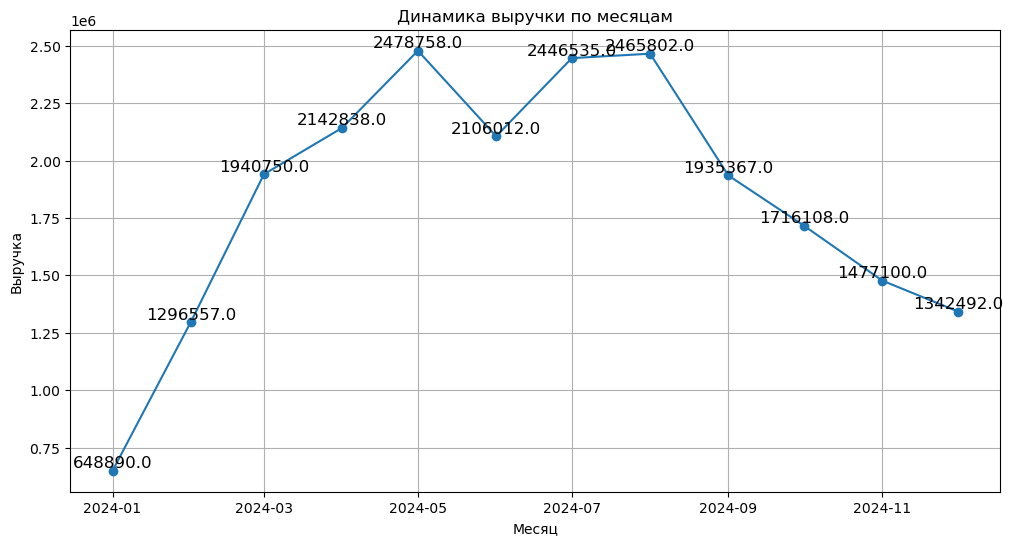

In [8]:
# Revenue (Посчитаю через сумму total_price, умноженную на 5%)
Revenue = (
    df_orders
    .groupby('order_month')['total_price']
    .sum() * 0.05
).reset_index().round()

Revenue = Revenue.rename(columns={'total_price': 'Revenue'})
display(Revenue.head(3))

# Строю график
plt.subplots(figsize=(12,6))
plt.plot(Revenue['order_month'], Revenue['Revenue'], marker='o') 

# Подписи точек
for x, y in zip(Revenue['order_month'], Revenue['Revenue']):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=12)


plt.title('Динамика выручки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')

plt.grid()
plt.show()

Выручка росла с января по май, достигнув пика в мае, после чего перешла в фазу снижения с кратковременным восстановлением летом (июль–август). С сентября наблюдается устойчивый спад выручки до конца года.

---

Чтобы понять, что именно пошло в сентябре не так, спускаюсь на уровень ниже и проверяю количество заказов.

,order_month,orders_count
0,2024-01-01,964
1,2024-02-01,1917
2,2024-03-01,2791


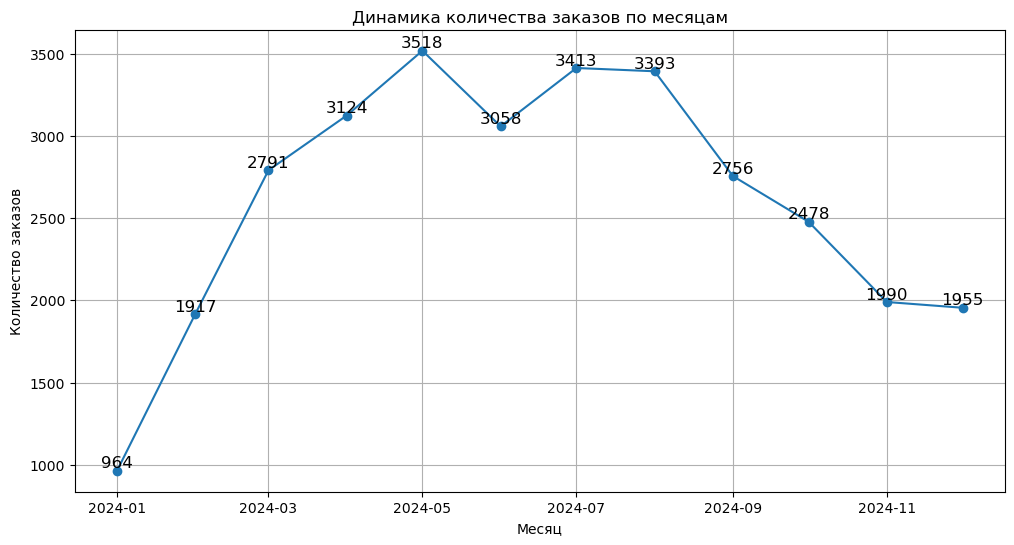

In [9]:
# Считаю динамику количества заказов
orders_all = (
    df_orders
    .groupby('order_month')['order_id']
    .nunique()
    .reset_index()
)

orders_all = orders_all.rename(columns={'order_id': 'orders_count'})
display(orders_all.head(3))

# Строю график
plt.subplots(figsize=(12,6))
plt.plot(orders_all['order_month'], orders_all['orders_count'], marker='o')  # маркеры для точек

# Подписи точек
for x, y in zip(orders_all['order_month'], orders_all['orders_count']):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=12)


plt.title('Динамика количества заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

plt.grid()
plt.show()

Тут аналогичная картина, до мая рост, летом спад и стагнация, с осени резкое падение. Только к концу года, в декабре, падение замедлилось, но, скорее всего, это тоже сезонное явление, так как к новому году количество заказов всегда растет. В начале года было 964 заказа, в мае был пик - 3518, в декабре 1955.

---

Сейчас есть пара предположений, почему может падать количество заказов: 1) поменялось что-то внутри сайта/приложения и людям стало неудобно использовать его; 2) поменялись товары на маркетплейсе и людям перестал нравиться ассортимент/часть товаров просто пропала. Для обоих предположений нужно подробно и сегментированно изучать данные. Так как сейчас я их смотрю верхнеуровнево, можно отталкиваться от того, что если проблемы будут с конверсией - следовательно что-то произошло с сайтом/приложением. Если же упал средний чек, то поменялся ассортимент. Это первые наметки и они могут поменяться далее, но пока рассмотрю средний чек, MAU и конверсию.

---

Дальше смотрю динамику среднего чека.

,order_month,avg,avg_smooth
0,2024-01-01,13462.0,NaN
1,2024-02-01,13527.0,13494.5
2,2024-03-01,13907.0,13717.0


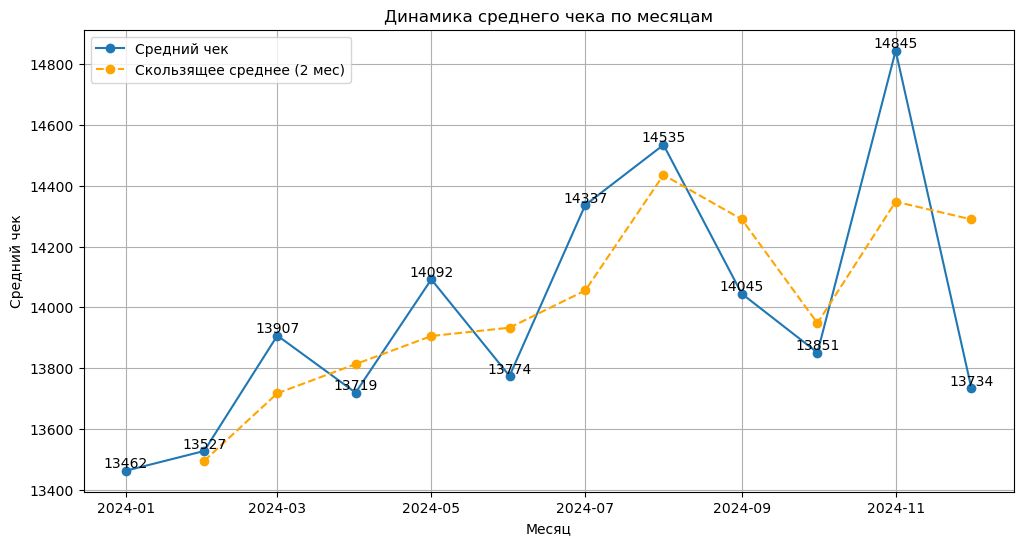

In [10]:
# AOV  
avg_month = (
    df_orders
    .groupby('order_month')['total_price']
    .mean()
    .reset_index()
    .round()
)

avg_month = avg_month.rename(columns={'total_price': 'avg'})

# Скользящее среднее (2 месяца)
avg_month['avg_smooth'] = avg_month['avg'].rolling(window=2, center=True).mean()
display(avg_month.head(3))



# Строю график
plt.figure(figsize=(12,6))

# Оригинальные значения
plt.plot(avg_month['order_month'], avg_month['avg'], marker='o', label='Средний чек')

# Скользящее среднее
plt.plot(avg_month['order_month'], avg_month['avg_smooth'], marker='o', linestyle='--', color='orange', label='Скользящее среднее (2 мес)')

# Подписи точек (оригинальные значения)
for x, y in zip(avg_month['order_month'], avg_month['avg']):
    plt.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=10)

plt.title('Динамика среднего чека по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средний чек')
plt.grid(True)
plt.legend()
plt.show()

Средний чек в течение года практически не меняется и все время находится в пределах от 13460 до 14845. Динамика роста видна по скользящему среднему. У него также есть скачок после сентября, но к падению к концу года это не привело.

---

Теперь считаю MAU.

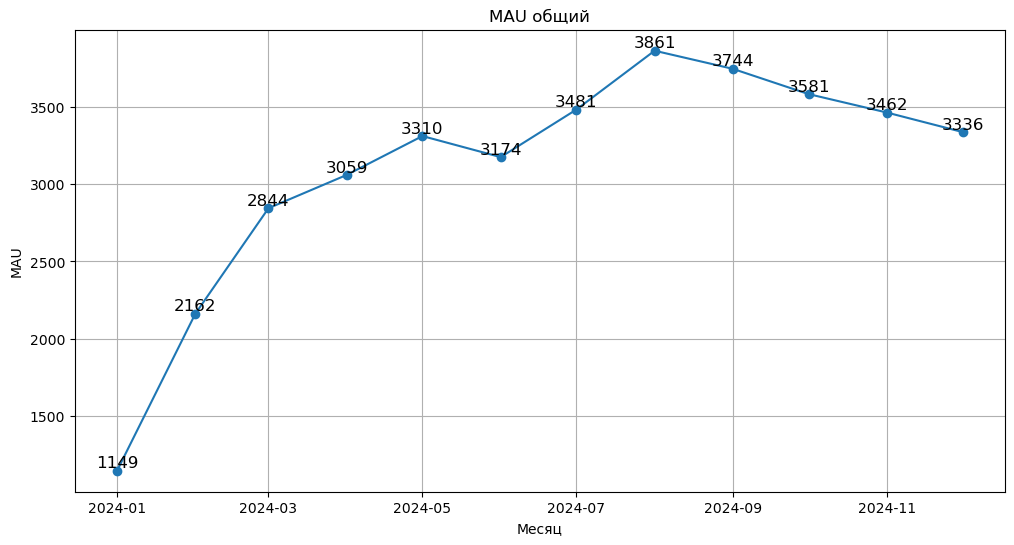

In [11]:
# Считаю MAU
mau_all = (
    df_events
    .groupby('event_month')['user_id']
    .nunique()
    .reset_index()
)
# print(mau_all)

# Строю график
plt.subplots(figsize=(12,6))
plt.plot(mau_all['event_month'], mau_all['user_id'], marker='o')  # маркеры для точек

# Подписи точек
for x, y in zip(mau_all['event_month'], mau_all['user_id']):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=12)


plt.title('MAU общий')
plt.xlabel('Месяц')
plt.ylabel('MAU')

plt.grid()
plt.show()

По MAU виден стабильный рост с начала года до начала лета. В июне произошел спад (вероятнее всего, из-за сезонности), затем снова рост. С сентября стабильное падение метрики от 3861 человека до 3336. Спад не резкий, но уверенный. 

----

Осталась конверсия в покупку. Ее буду считать как "пользователи, совершившие покупку, разделенные на пользователей, зашедших в продукт". Конверсия по шагам воронки будет позже, так как она более углубленная.

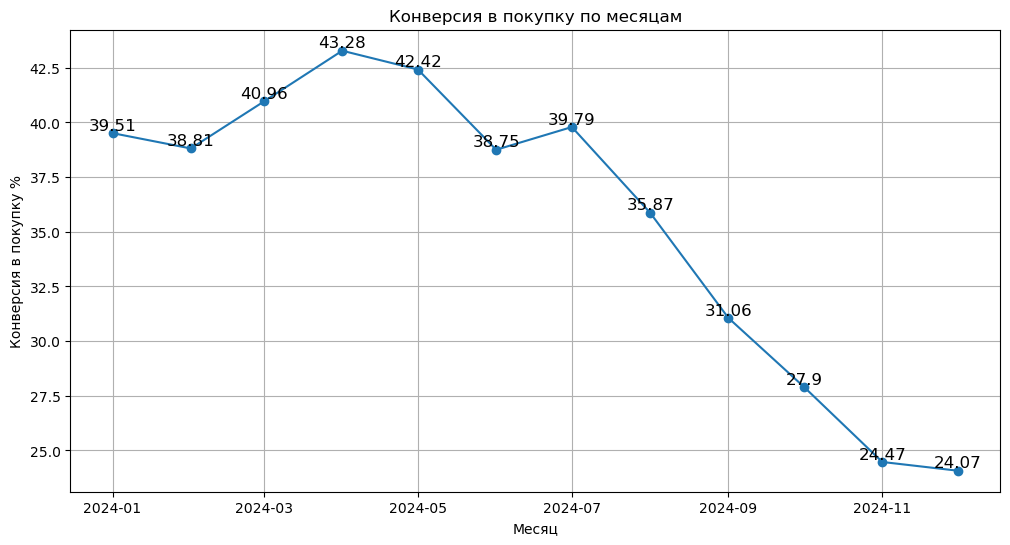

In [12]:
# Считаю уникальных пользователей с покупкой по месяцу
users_buy_month = (
    df_orders
    .groupby('order_month')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'users_buy'})
)

# Объединяю с MAU по месяцам
cr = mau_all.merge(users_buy_month, left_on='event_month', right_on='order_month', how='left')

# Считаю конверсию
cr['CR'] = ((cr['users_buy'] / cr['user_id']) * 100).round(2)


# Строю график
plt.subplots(figsize=(12,6))
plt.plot(cr['event_month'], cr['CR'], marker='o')  # маркеры для точек

# Подписи точек
for x, y in zip(cr['event_month'], cr['CR']):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=12)


plt.title('Конверсия в покупку по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Конверсия в покупку %')

plt.grid()
plt.show()

А тут картина отличается от других графиков. Рост до апреля был небольшой, на 3,5%. Но начиная с мая пошел спад и к декабрю конверсия в покупку уменьшилась более чем в 1,5 раза.

Эта динамика не похожа на остальные графики. Чтобы понять, куда копать дальше, проверю конверсию в заказ. Если проблема будет там, возможно, проблему стоит искать на сайте/в приложении. Если же там конверсия не будет так сильно падать, то проблема может быть именно с оплатой товара (на пункте выдачи или с банками)

---

Проверяю конверсию в заказ.

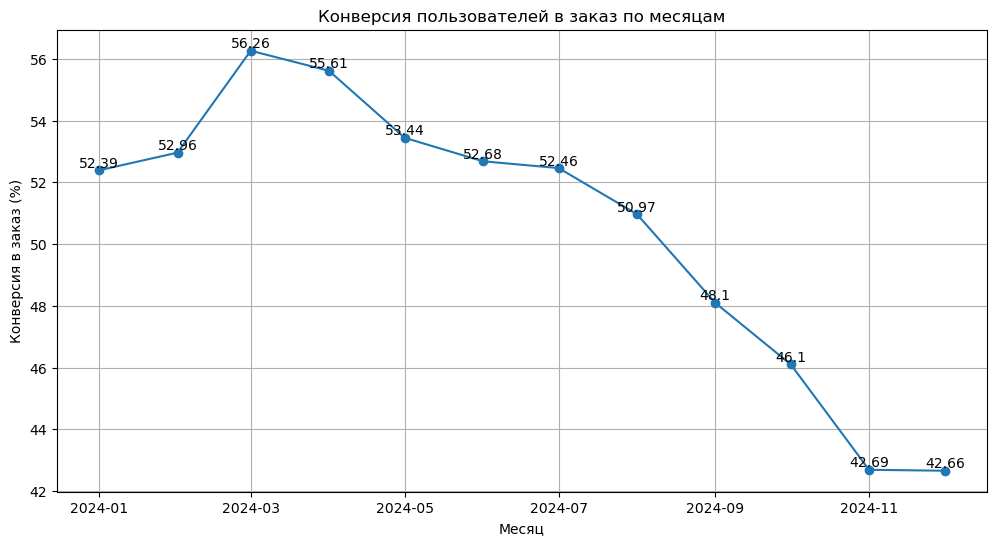

In [13]:
# MAU по месяцам (все заходы в продукт)
mau_app = (
    df_events[['user_id', 'event_month']]
    .drop_duplicates()
    .groupby('event_month')['user_id']
    .nunique()
    .reset_index()
)

# Уникальные пользователи с checkout_complete
users_order_event = (
    df_events[df_events['event_type'] == 'checkout_complete'][['user_id', 'event_month']]
    .drop_duplicates()
)

# Пользователи с заказом по месяцам
orders_month = (
    users_order_event
    .groupby('event_month')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'users_order'})
)

# Объединяю и считаю конверсию
cr_order_df = mau_app.merge(orders_month, on='event_month', how='left')
cr_order_df['users_order'] = cr_order_df['users_order'].fillna(0)
cr_order_df['CR_order_pct'] = (cr_order_df['users_order'] / cr_order_df['user_id'] * 100).round(2)


# График конверсии
plt.figure(figsize=(12,6))
plt.plot(cr_order_df['event_month'], cr_order_df['CR_order_pct'], marker='o', linestyle='-')
for x, y in zip(cr_order_df['event_month'], cr_order_df['CR_order_pct']):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=10)
plt.title('Конверсия пользователей в заказ по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Конверсия в заказ (%)')
plt.grid(True)
plt.show()


Конверсия в заказ также падает, причем началось это еще раньше, чем падение конверсии в покупку, а именно с апреля. С 52% к марту конверсия выросла до 56%, а к декабрю упала до 42,5%.

----

Так как пока что картина не ясна и мы видим только падания метрик, но с разных временных точек, проведу сегментацию по `Revenue`, чтобы можно было лучше понимать, где искать проблему. Разделю данные по полу, региону, и операционной системе (внутри этой категории мы увидим и результаты для типа девайса). 

Сейчас есть такие теории:

- если падение в одном регионе, возможна сломанная логистика

- если расходятся ОС, возможен баг в технической или платёжной истории

- если отличается по полу, то вопрос ассортимента, собственного позиционирования маркетплейса (его бренда)

,order_month,gender,Revenue
0,2024-01-01,F,283805.0
1,2024-01-01,M,339681.0
2,2024-02-01,F,573307.0


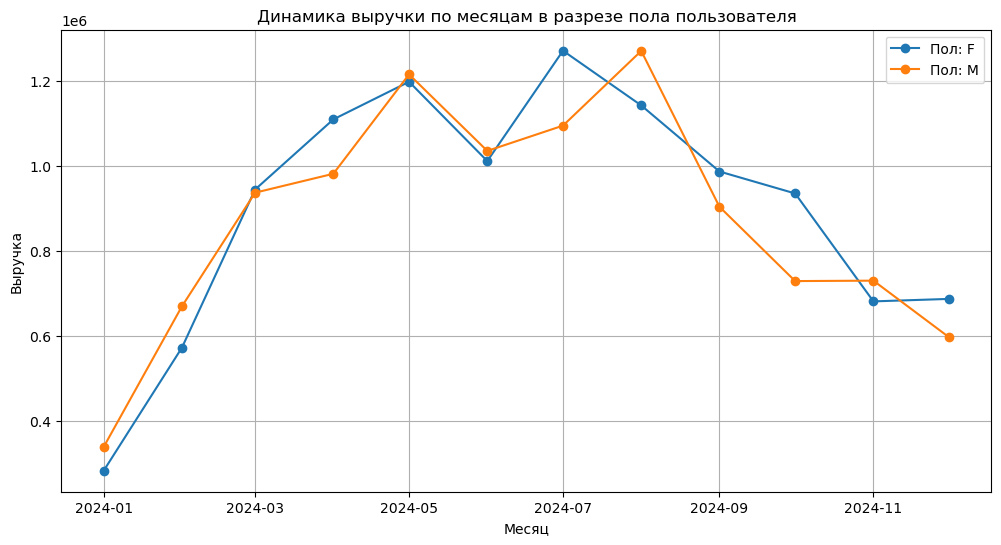

In [14]:
# Оставляю нужные поля из users
users_gender = df_users[['user_id', 'gender']]

# Мержу с заказами
orders_gender = df_orders.merge(
    users_gender,
    on='user_id',
    how='left'
)

revenue_gender = (
    orders_gender
    .groupby(['order_month', 'gender'])['total_price']
    .sum()
    .mul(0.05)
    .reset_index()
    .round()
    .rename(columns={'total_price': 'Revenue'})
)

display(revenue_gender.head(3))

#Строя график
plt.figure(figsize=(12,6))

for gender in revenue_gender['gender'].unique():
    data = revenue_gender[revenue_gender['gender'] == gender]
    plt.plot(
        data['order_month'],
        data['Revenue'],
        marker='o',
        label=f'Пол: {gender}'
    )

plt.title('Динамика выручки по месяцам в разрезе пола пользователя')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid()
plt.legend()
plt.show()


По половому признаку пользователей разница слабая и спад после летних месяцев присутствует на обоих графиках.

,order_month,os,Revenue
0,2024-01-01,Android,147997.0
1,2024-01-01,Windows,93059.0
2,2024-01-01,iOS,129159.0


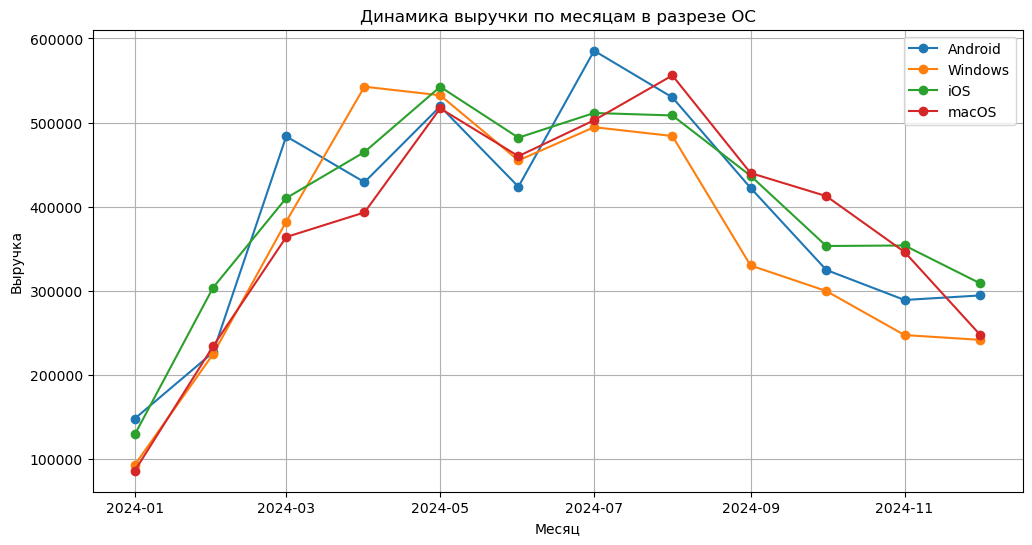

In [15]:
# ОС
users_os_month = (
    df_events
    [['user_id', 'event_month', 'os']]
    .drop_duplicates()
)

orders_os = df_orders.merge(
    users_os_month,
    left_on=['user_id', 'order_month'],
    right_on=['user_id', 'event_month'],
    how='left'
)

revenue_os = (
    orders_os
    .groupby(['order_month', 'os'])['total_price']
    .sum()
    .mul(0.05)
    .reset_index()
    .round()
    .rename(columns={'total_price': 'Revenue'})
)

display(revenue_os.head(3))


# Строю график
plt.figure(figsize=(12,6))

for os_name in revenue_os['os'].dropna().unique():
    data = revenue_os[revenue_os['os'] == os_name]
    plt.plot(
        data['order_month'],
        data['Revenue'],
        marker='o',
        label=os_name
    )

plt.title('Динамика выручки по месяцам в разрезе ОС')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid()
plt.legend()
plt.show()


Операционные системы также не показывают что-то новое.

---

Остались регионы.

,order_month,region,Revenue
0,2024-01-01,Другие регионы,206508.0
1,2024-01-01,Екатеринбург,19770.0
2,2024-01-01,Краснодар,26599.0


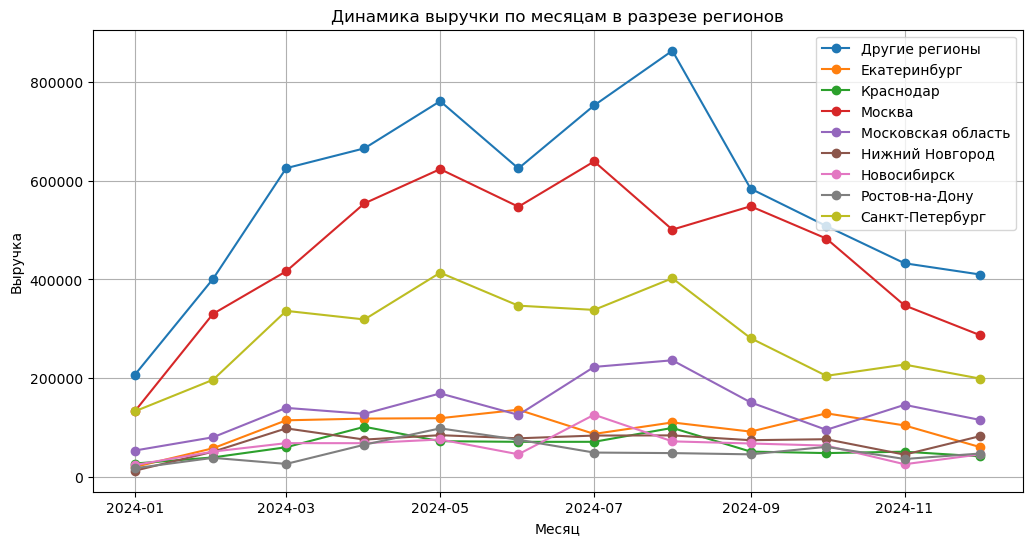

In [16]:
# Регион
users_region = df_users[['user_id', 'region']]

# Мержу
orders_region = df_orders.merge(
    users_region,
    on='user_id',
    how='left'
)

revenue_region = (
    orders_region
    .groupby(['order_month', 'region'])['total_price']
    .sum()
    .mul(0.05)
    .reset_index()
    .round()
    .rename(columns={'total_price': 'Revenue'})
)

display(revenue_region.head(3))

plt.figure(figsize=(12,6))

for region in revenue_region['region'].unique():
    data = revenue_region[revenue_region['region'] == region]
    plt.plot(
        data['order_month'],
        data['Revenue'],
        marker='o',
        label=region
    )

plt.title('Динамика выручки по месяцам в разрезе регионов')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid()
plt.legend()
plt.show()


На самых крупных по выручке регионах видно рост вначале года, волатильность в середине и спад к концу. Но на менее денежных эту тенженцию сложно увидеть, поэтому добавлю нормализованный график.

,order_month,region,Revenue,Revenue_index
0,2024-01-01,Другие регионы,206508.0,0.0
9,2024-02-01,Другие регионы,401085.0,29.6
18,2024-03-01,Другие регионы,625598.0,63.8


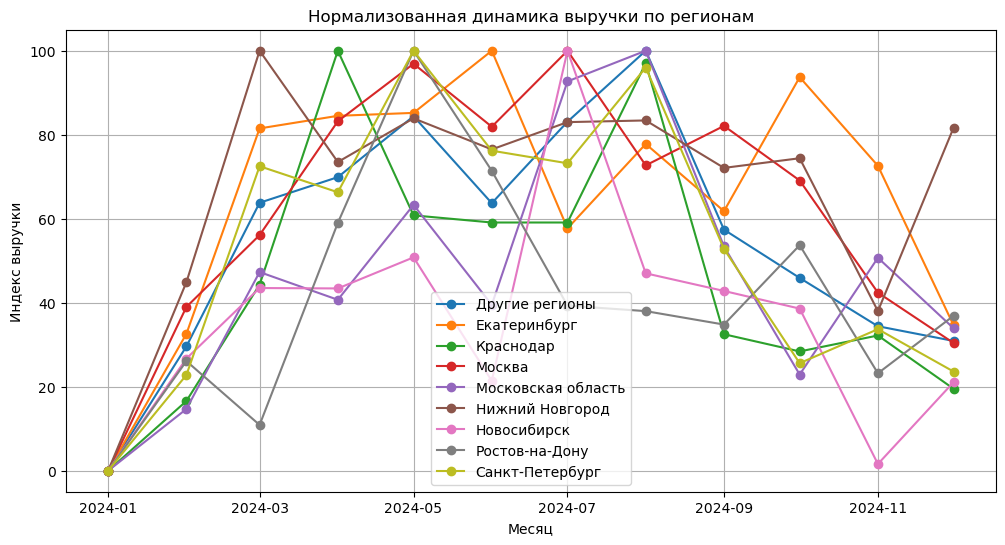

In [17]:
# Revenue index
revenue_region = revenue_region.sort_values(['region', 'order_month'])

# Min-max нормализация внутри региона
revenue_region['Revenue_index'] = (
    revenue_region
    .groupby('region')['Revenue']
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()) * 100)
).round(1)

display(revenue_region.head(3))

# График
plt.figure(figsize=(12,6))

for region in revenue_region['region'].unique():
    data = revenue_region[revenue_region['region'] == region]
    plt.plot(
        data['order_month'],
        data['Revenue_index'],
        marker='o',
        label=region
    )

plt.title('Нормализованная динамика выручки по регионам')
plt.xlabel('Месяц')
plt.ylabel('Индекс выручки')
plt.grid()
plt.legend()
plt.show()



На это график в целом видно ту же дугу:

- Пиковые периоды роста: февраль–май, июль–август.

- Периоды спада: лето и осень, чаще всего после кратковременных пиков.

- Нижний Новгород и некоторые южные города имеют менее выраженные спады к концу года — динамика более стабильная.

---

---

**Вывод по сегментации выручки (пол, ОС, регионы):** значимых различий не обнаружено — спад выручки присутствует во всех срезах равномерно. Это важный результат: он исключает технические и логистические причины падения (баг на конкретной платформе, проблему в отдельном регионе). Проблема системная и затрагивает продукт в целом.


**Вывод по верхнеуровневому анализу**:

**Выручка**

- С января по май наблюдается постоянный рост выручки: с 0,65 млн ₽ до 2,48 млн ₽.

- В июне выручка немного снижается (2,11 млн ₽), затем снова растёт в июле-августе (≈2,45 млн ₽).

С сентября начинается постепенное снижение к концу года, до 1,34 млн ₽ в декабре.

Вывод: сезонность + пик активности в весенне-летний период, спад в осенне-зимний период.

--- 

**Количество заказов**

Тренд повторяет выручку: рост с января (964 заказа) до мая (3518), затем небольшой спад в июне, повторный рост в июле-августе и снижение с сентября до декабря (1955 заказов).

Паттерн указывает на влияние сезонности на активность покупателей.

--- 

**Средний чек**

Средний чек относительно стабилен, колебания в диапазоне 13–14,8 тыс ₽.

С апреля по август наблюдается рост среднего чека, максимальное значение — август (14,535 ₽).

В ноябре средний чек достигает локального максимума (14,845 ₽), затем в декабре падает (13,734 ₽).

Вывод: рост среднего чека не полностью коррелирует с количеством заказов, что указывает на влияние крупных покупок в отдельные месяцы.

--- 

**MAU** (активные пользователи)

MAU растёт с января (1149) до августа (3861), затем постепенно снижается до декабря (3336).

Тренд подтверждает рост пользовательской базы в первой половине года и лёгкий спад к концу года.

--- 

**Конверсия в покупку** (из MAU)

Пик конверсии наблюдается в апреле — 43,3%.

С мая начинается снижение: к декабрю конверсия падает до 24%.

Вывод: хотя активность пользователей растёт летом, конверсия в покупку падает, вероятно, из-за роста MAU за счёт менее целевых пользователей.

--- 

**Конверсия в заказ** (все заказы, без оплаты)

Конверсия стабильна на уровне 50–56% с января по август.

С сентября наблюдается плавное снижение до 42,6% в декабре.

Вывод: пользователи продолжают делать заказы, но доля заказов относительно всех активных пользователей снижается к концу года.

--- 

**Сегментация** по полу, ОС и регионам не выявила значимых различий.

---

**Итоговая динамика**

Рост метрик: январь–май (выручка, заказы, MAU, CR).

Стабилизация: июнь–август (выручка и заказы высокие, средний чек растёт).

Спад: сентябрь–декабрь (снижение заказов, выручки и конверсий).

Средний чек и конверсии показывают, что рост MAU не всегда сопровождается ростом выручки - часть новых пользователей менее активны.

---

**Итоговый вывод**

Маркетплейс демонстрировал рост в начале года, но с весны/лета появляются тревожные сигналы: пользователи заходят, но меньше покупают, что ведёт к падению выручки.

## 3. Юнит-экономика и монетизация

`Revenue` и `AOV` уже посчитаны. Дальше буду считать `ARPU` и `ARPPU`. Разница между `ARPU` и `ARPPU` фактически покажет вклад конверсии в покупку в падение выручки. 

,order_month,arpu,arppu
0,2024-01-01,11295.0,28585.46
1,2024-02-01,11994.0,30907.20
2,2024-03-01,13648.0,33317.59


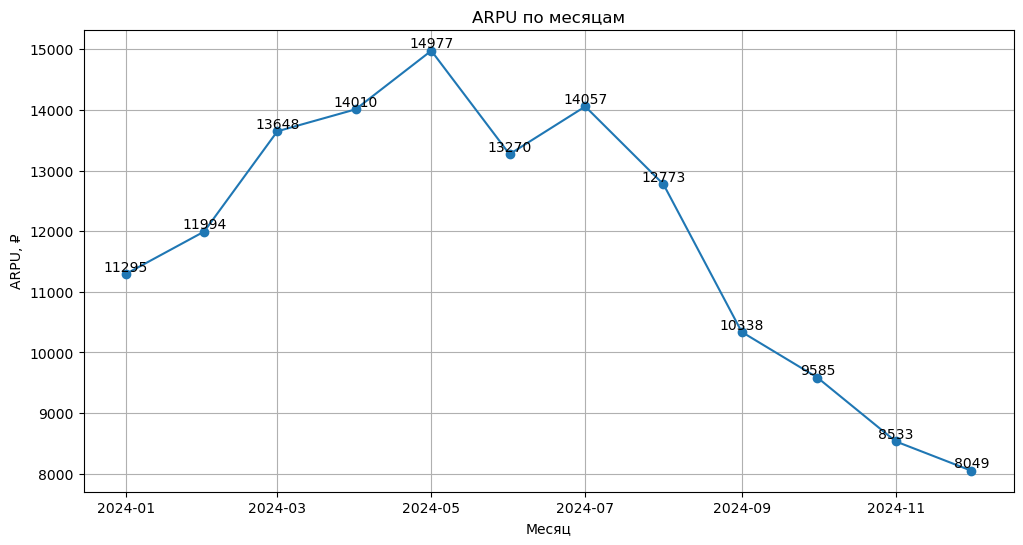

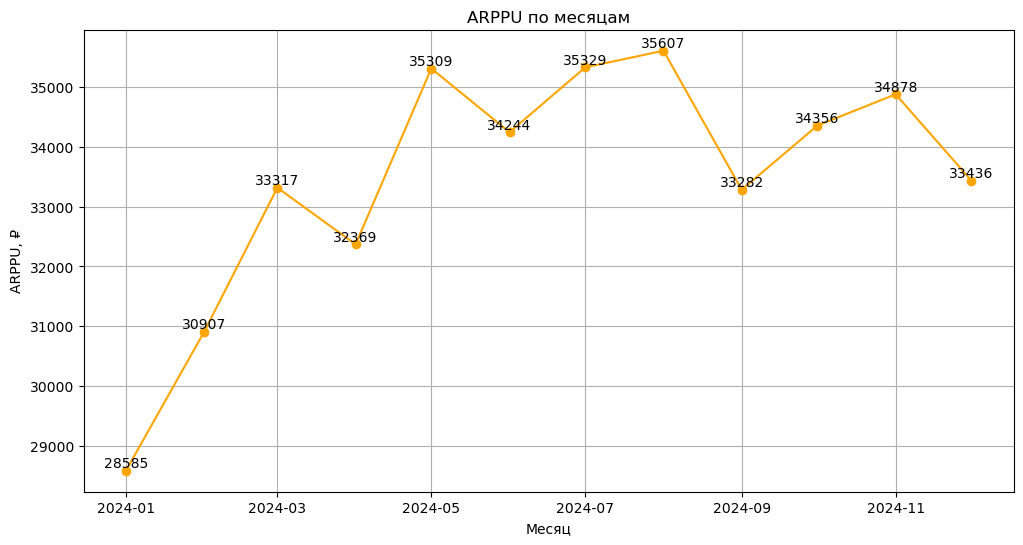

In [18]:
# Рассчитываю ARPU и ARPPU через вспомогательную функцию
arpu_arppu = calc_arpu_arppu(df_orders, mau_all, users_buy_month)

# Отображаю первые строки
display(arpu_arppu.head(3))

# График ARPU
plt.figure(figsize=(12, 6))
plt.plot(arpu_arppu['order_month'], arpu_arppu['arpu'], marker='o', label='ARPU')
for x, y in zip(arpu_arppu['order_month'], arpu_arppu['arpu']):
    plt.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=10)
plt.title('ARPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPU, ₽')
plt.grid(True)
plt.show()

# График ARPPU
plt.figure(figsize=(12, 6))
plt.plot(arpu_arppu['order_month'], arpu_arppu['arppu'], marker='o', label='ARPPU', color='orange')
for x, y in zip(arpu_arppu['order_month'], arpu_arppu['arppu']):
    plt.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=10)
plt.title('ARPPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPPU, ₽')
plt.grid(True)
plt.show()


Динамика ARPU похожа на динамику конверсии в покупку и общей выручки. В начале года средний доход на пользователя равен 11300, в мае пик почти 14980, в июне просадка, с сентября падение и к концу года 8050. Это может быть связано с приходом "холодных", не платящих пользователей.



ARPPU в целом растёт, то есть средний доход на платящего пользователя увеличивается. Это может означать:
- ядро платящих пользователей тратит больше,
- возможно, растёт доля heavy users

---

Учитывая разнонаправленные графики ARPU и ARPPU, могу сказать, что основной риск маркетплейса - снижение эффективности воронки в продажу.

---

Дальше посчитаю CAC, чтобы убедиться, что привлечение стало хуже окупаться.

,month,new_users,budget,CAC
0,2024-01-01,2985,1.177457e+06,394.457945
1,2024-02-01,2711,1.061386e+06,391.510856
2,2024-03-01,2965,1.167680e+06,393.821373


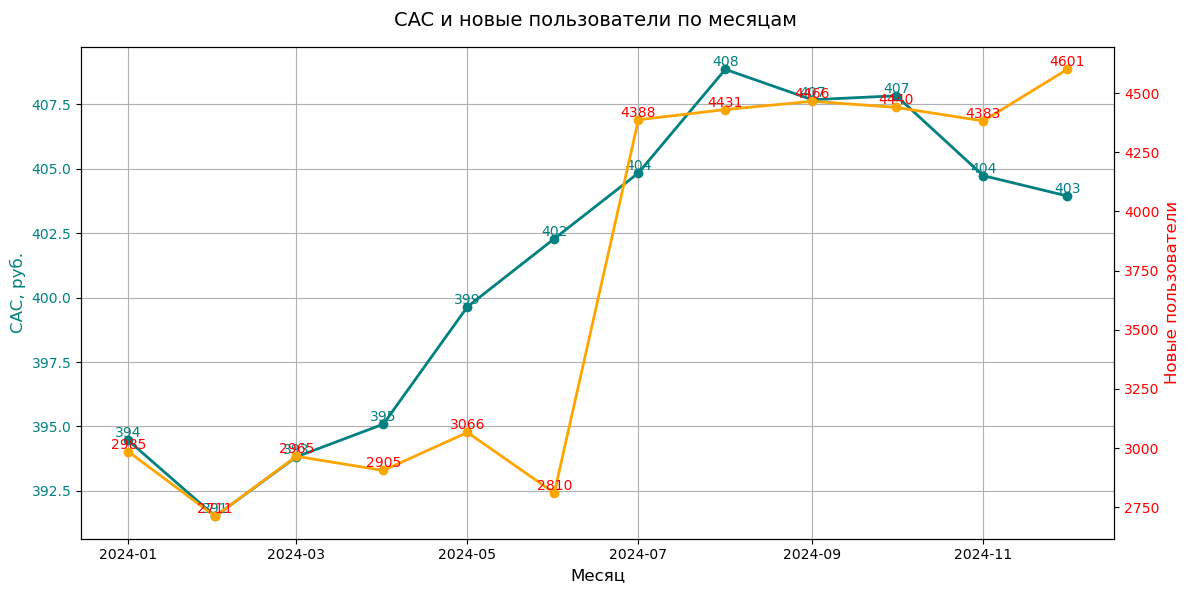

In [19]:
# Считаю количество новых пользователей по месяцам 
new_users_monthly = (
    df_users
    .groupby('cohort_month', as_index=False)['user_id']
    .nunique()
    .rename(columns={'user_id': 'new_users'})
)

# Считаю бюджет по месяцам
budget_monthly = (
    df_camp
    .groupby('spend_month', as_index=False)['budget']
    .sum()
    .rename(columns={'spend_month': 'month'})
)

# Мержу
cac_df = (
    new_users_monthly
    .rename(columns={'cohort_month': 'month'})
    .merge(budget_monthly, on='month', how='left')
)

# Считаю CAC ---
cac_df['CAC'] = cac_df['budget'] / cac_df['new_users']

cac_df = cac_df.sort_values('month')
display(cac_df.head(3))

# График
fig, ax1 = plt.subplots(figsize=(12,6))

# Левая ось: CAC
ax1.plot(cac_df['month'], cac_df['CAC'], marker='o', color='teal', linewidth=2, label='CAC, руб.')
for x, y in zip(cac_df['month'], cac_df['CAC']):
    ax1.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=10, color='teal')
ax1.set_xlabel('Месяц', fontsize=12)
ax1.set_ylabel('CAC, руб.', fontsize=12, color='teal')
ax1.tick_params(axis='y', labelcolor='teal')
ax1.grid(True)

# Правая ось: новые пользователи
ax2 = ax1.twinx()
ax2.plot(cac_df['month'], cac_df['new_users'], marker='o', color='orange', linewidth=2, label='Новые пользователи')
for x, y in zip(cac_df['month'], cac_df['new_users']):
    ax2.text(x, y, str(y), ha='center', va='bottom', fontsize=10, color='red')
ax2.set_ylabel('Новые пользователи', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.suptitle('CAC и новые пользователи по месяцам', fontsize=14)
fig.tight_layout()
plt.xticks(rotation=45)
plt.show()

CAC колеблется в диапазоне ~390–410 руб. за пользователя и постепенно растёт к концу года, несмотря на рост числа новых пользователей. Самые высокие значения наблюдаются в августе–декабре, когда расходы на маркетинг чуть превышают рост новой аудитории.

---

Считаю ROI


,spend_month,budget,GMV,roi
0,2024-01-01,1.177457e+06,12977800.53,10.02
1,2024-02-01,1.061386e+06,25931140.19,23.43
2,2024-03-01,1.167680e+06,38814995.89,32.24


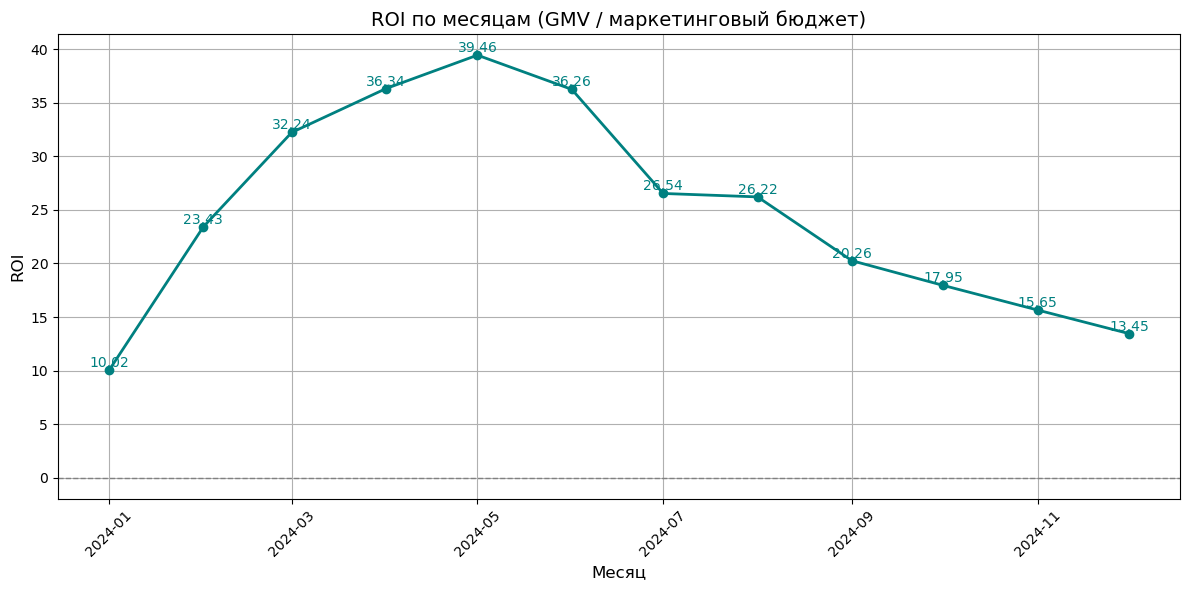

In [20]:
# Считаю ROI как отношение выручки маркетплейса к маркетинговым расходам.
# Revenue — комиссия 5% от GMV. Чтобы сравнение было корректным,
# ROI считается на основе GMV (полного объёма продаж), а не только комиссии.

# GMV по месяцам
gmv_monthly = (
    df_orders
    .groupby('order_month')['total_price']
    .sum()
    .reset_index()
    .rename(columns={'total_price': 'GMV'})
)

# Бюджет по месяцам
budget_monthly = (
    df_camp
    .groupby('spend_month')['budget']
    .sum()
    .reset_index()
)

# Объединяю
roi_df = budget_monthly.merge(
    gmv_monthly,
    left_on='spend_month',
    right_on='order_month',
    how='left'
)

roi_df = roi_df.dropna(subset=['GMV'])

# ROI = (GMV - бюджет) / бюджет
roi_df['roi'] = ((roi_df['GMV'] - roi_df['budget']) / roi_df['budget']).round(2)

display(roi_df[['spend_month', 'budget', 'GMV', 'roi']].head(3))

# График
plt.figure(figsize=(12, 6))
plt.plot(roi_df['spend_month'], roi_df['roi'], marker='o', color='teal', linewidth=2)
for x, y in zip(roi_df['spend_month'], roi_df['roi']):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='teal')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('ROI по месяцам (GMV / маркетинговый бюджет)', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('ROI', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


ROI рассчитан как отношение GMV (полного объёма продаж) к маркетинговому бюджету.

В январе–феврале ROI ниже 1 — объём продаж ещё не перекрывает маркетинговые расходы. С марта GMV устойчиво превышает бюджет, ROI достигает максимума в мае. После лета показатель постепенно снижается, к декабрю приближаясь к минимальным значениям года.

---

Считаю Payback Period.


,month,Revenue,budget,cum_revenue,cum_costs,cum_profit
0,2024-01-01,648890.0,1.177457e+06,648890.0,1.177457e+06,-528566.966250
1,2024-02-01,1296557.0,1.061386e+06,1945447.0,2.238843e+06,-293395.896250
2,2024-03-01,1940750.0,1.167680e+06,3886197.0,3.406523e+06,479673.733125


Payback Period достигнут в месяце: 2024-03-01 00:00:00


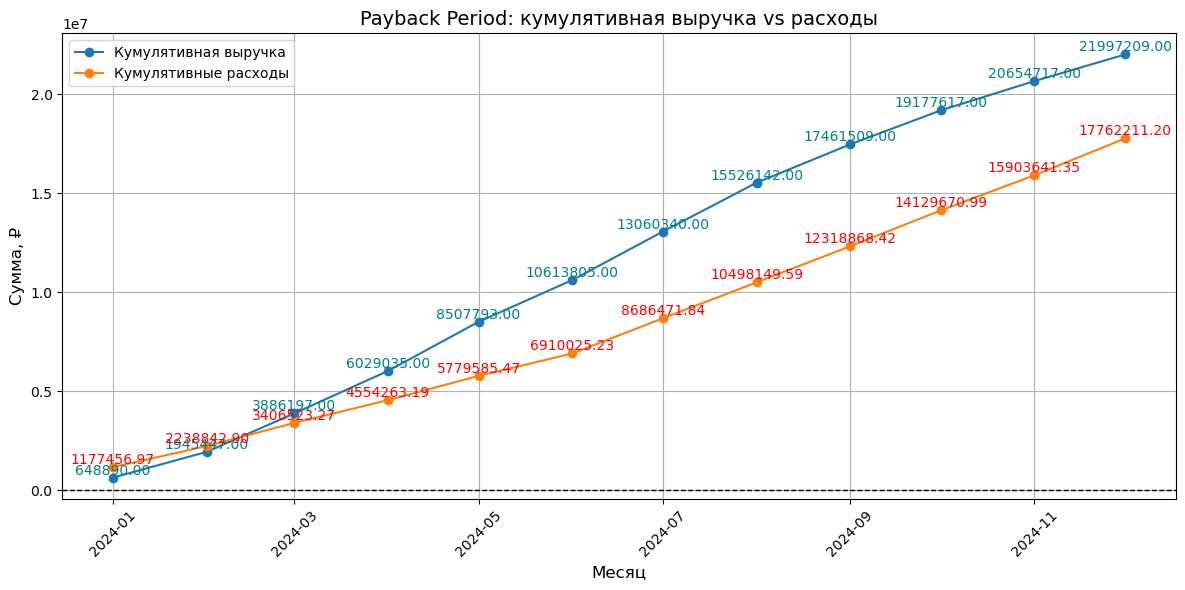

In [21]:
# Мержу месячную выручку с бюджетом
payback_df = (
    Revenue.rename(columns={'order_month':'month'})  # используем уже посчитанную Revenue
    .merge(
        df_camp.groupby('spend_month', as_index=False)['budget'].sum().rename(columns={'spend_month':'month'}),
        on='month',
        how='left'
    )
    .sort_values('month')
)

payback_df['budget'] = payback_df['budget'].fillna(0)

# Считаю кумулятивные показатели
payback_df['cum_revenue'] = payback_df['Revenue'].cumsum()
payback_df['cum_costs'] = payback_df['budget'].cumsum()
payback_df['cum_profit'] = payback_df['cum_revenue'] - payback_df['cum_costs']

display(payback_df.head(3))

# Payback Period 
payback_point = payback_df[payback_df['cum_profit'] >= 0].head(1)

if not payback_point.empty:
    payback_month = payback_point['month'].iloc[0]
    print(f'Payback Period достигнут в месяце: {payback_month}')
else:
    print('Payback Period не достигнут за период наблюдения')

# График
plt.figure(figsize=(12,6))
plt.plot(payback_df['month'], payback_df['cum_revenue'], marker='o', label='Кумулятивная выручка')
plt.plot(payback_df['month'], payback_df['cum_costs'], marker='o', label='Кумулятивные расходы')
plt.axhline(0, color='black', linewidth=1, linestyle='--')

for x, y in zip(payback_df['month'], payback_df['cum_revenue']):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='teal')
for x, y in zip(payback_df['month'], payback_df['cum_costs']):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='red')
    
plt.title('Payback Period: кумулятивная выручка vs расходы', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Сумма, ₽', fontsize=12)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Окупаемость (Payback Period) достигнута в марте 2024 года — к этому моменту кумулятивная выручка покрыла все накопленные маркетинговые расходы. До марта компания работала в минусе, а с марта и дальше каждая следующая продажа приносит чистую прибыль сверх затрат.

---

Выводы по монетизации и юнит-экономике:

1. **Доход на пользователя**:

- ARPU рос с января по май (11 300 → 14 980) и падал к концу года (8 050), что отражает снижение конверсии в покупку.

- ARPPU стабильно растёт, что показывает, что платящие пользователи тратят больше — ядро платящих пользователей остаётся активным.

2. **Стоимость привлечения (CAC)**:

- Колеблется около 390–410 ₽, постепенно растёт к концу года. Привлечение становится чуть менее эффективным, особенно в августе–декабре.

3. **ROI**:

- Отрицательный в начале года (январь −0,45), затем положительный с марта по июнь, максимум в мае (1,02). После лета ROI падает и к декабрю снова отрицательный (−0,28).

**Окупаемость (Payback Period)**:

- Достигнута в марте 2024 года. С этого момента каждая новая продажа приносит чистую прибыль сверх маркетинговых расходов.

---

**Ключевой инсайт**:
Основной риск — падение конверсии в покупку. Платящие пользователи остаются активными, но рост аудитории не полностью конвертируется в покупки. Задача продукта — повысить эффективность воронки и удержание новых пользователей.

## Выводы по этапам 2 и 3


 **Ключевые выводы по продукту и монетизации**

**Этап 2 — Верхнеуровневая оценка состояния продукта:**  

Маркетплейс демонстрировал рост активности и выручки с января по май 2024 года: 
- MAU увеличивался с 1 149 до 3 310
- количество заказов с 964 до 3 518
- средний чек оставался стабильным (13–14 тыс. руб.)
- конверсия в покупку росла до апреля и затем начала снижаться

С июня по август наблюдалась сезонная стагнация, а с сентября показатели стали падать: 
- MAU снизился с 3861 в августе до 3 336 в декабре
- количество заказов уменьшилось до 1 955
- конверсия в покупку упала с 43,3% до 24%

Снижение конверсии при стабильном среднем чеке может указывать на проблемы с воронкой и эффективностью процесса покупки.

---

**Этап 3 — Метрики монетизации и юнит-экономика:**  
- ARPU повторяет динамику выручки, падая к концу года с 11 300 до 8 050 руб.
- ARPPU растёт (28–35 тыс. руб.), что подтверждает активность ядра платящих пользователей
- CAC колеблется в пределах 390–410 руб., постепенно растёт к концу года
- ROI максимальный в мае (1,02), затем снижается до отрицательных значений в декабре (−0,28)
- Payback Period достигнут в марте, после чего каждая продажа приносит чистую прибыль

Основной риск маркетплейса — снижение эффективности воронки и падение конверсии новых пользователей, что влияет на общую выручку и рост бизнеса.

---


## 4. Сегментация, воронки и инсайты


Посчитаю воронку в покупку, рассматривая все основные этапы.

,step,users,conversion,step_conversion
0,page_view,22098,1.000000,1.000000
1,product_view,22069,0.998688,0.998688
2,add_to_cart,20411,0.923658,0.924872
3,checkout_start,16769,0.758847,0.821567
4,checkout_complete,13897,0.628880,0.828732
5,purchase,8922,0.403747,0.642009


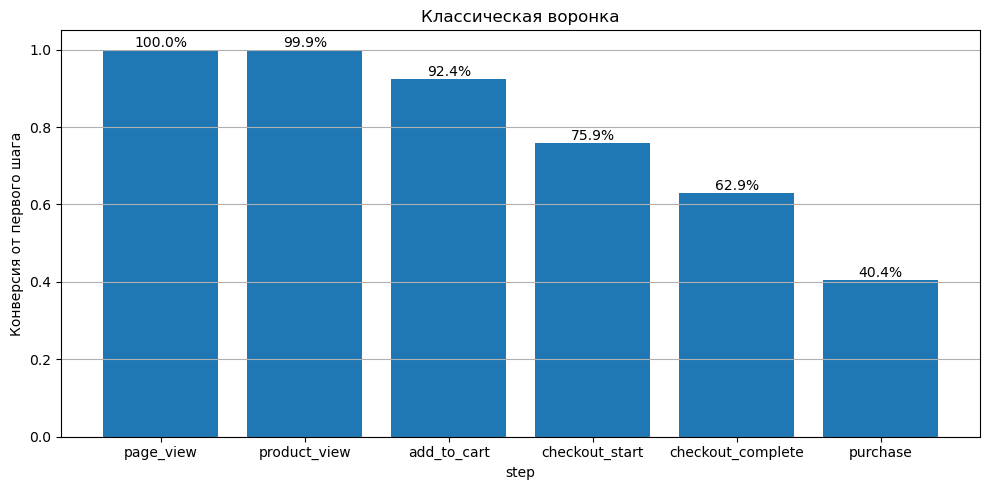

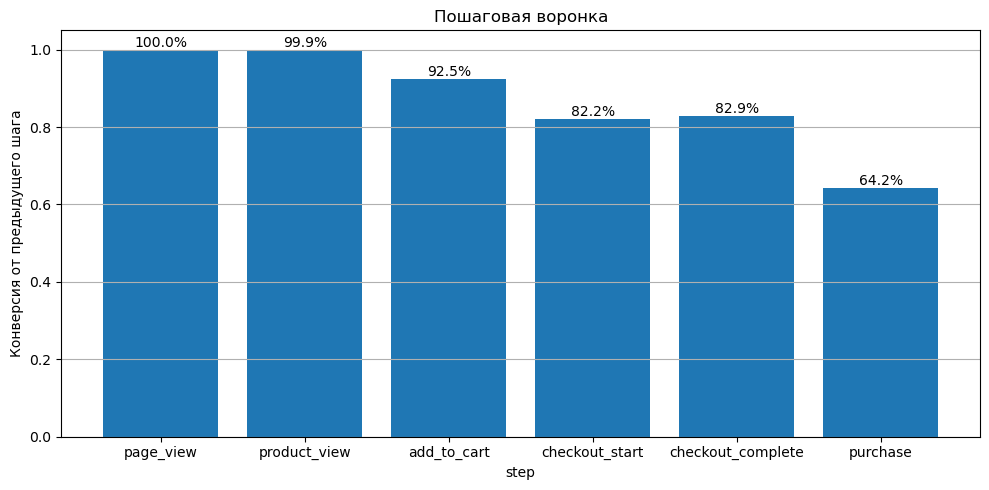

In [22]:
# Считаю конверсию (включая покупку)

# Шаги воронки
steps = [
    'page_view',
    'product_view',
    'add_to_cart',
    'checkout_start',
    'checkout_complete',
    'purchase'
]

# Пользователи на шагах из Events
events_steps = steps[:-1] 

funnel_counts = (
    df_events[df_events['event_type'].isin(events_steps)]
    .groupby('event_type')['user_id']
    .nunique()
    .reindex(events_steps)
    .reset_index()
)

funnel_counts.columns = ['step', 'users']

# Пользователи с покупкой (из Orders)
purchase_users = (
    df_orders['user_id']
    .nunique()
)

# Добавляем шаг purchase
funnel_counts = pd.concat(
    [
        funnel_counts,
        pd.DataFrame(
            {'step': ['purchase'], 'users': [purchase_users]}
        )
    ],
    ignore_index=True
)

# Классическая конверсия
funnel_counts['conversion'] = (
    funnel_counts['users'] / funnel_counts.loc[0, 'users']
)

# Пошаговая конверсия
funnel_counts['step_conversion'] = (
    funnel_counts['users'] / funnel_counts['users'].shift(1)
)
funnel_counts.loc[0, 'step_conversion'] = 1

display(funnel_counts)

# Классическая воронка
plot_bar_with_labels(
    funnel_counts,
    x_col='step',
    y_col='conversion',
    title='Классическая воронка',
    ylabel='Конверсия от первого шага',
    is_percent=True
)

# Пошаговая воронка
plot_bar_with_labels(
    funnel_counts,
    x_col='step',
    y_col='step_conversion',
    title='Пошаговая воронка',
    ylabel='Конверсия от предыдущего шага',
    is_percent=True
)

По общей воронке видно, что верх воронки почти без потерь, но основные оттоки начинаются после добавления в корзину. Самый критичный этап — переход от завершения оформления к покупке: до оплаты доходит лишь ~64% пользователей. Итоговая конверсия в покупку составляет ~40% от всех, кто начал путь с просмотра страницы.

---

Рассмотрю воронку по сегментам. По регионам, возрастам пользователей и операционным системам.

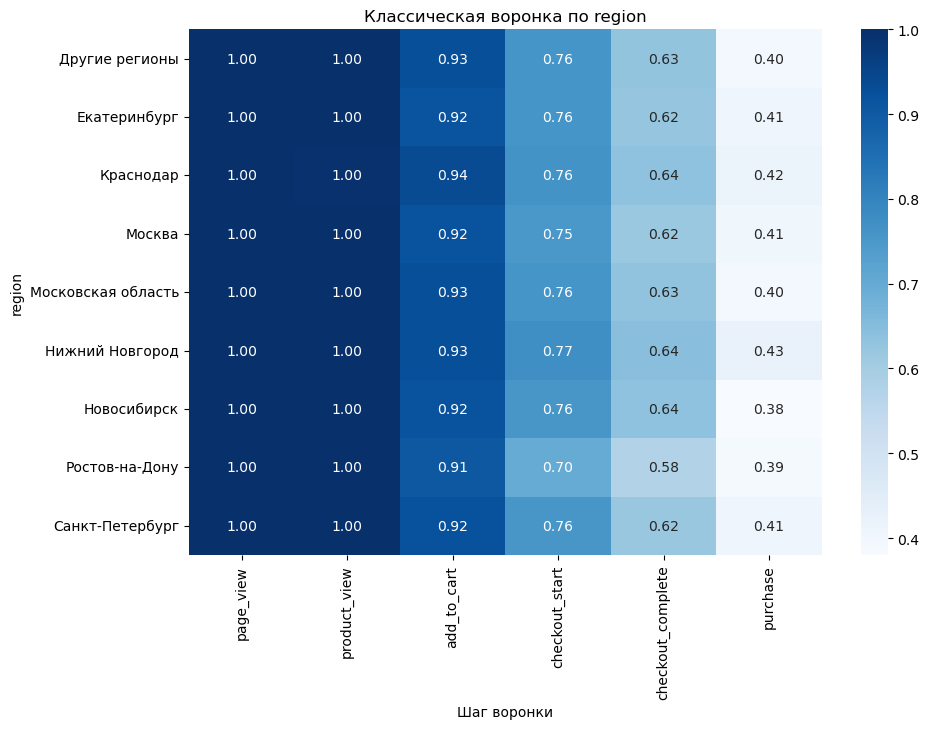

step,page_view,product_view,add_to_cart,checkout_start,checkout_complete,purchase
region,,,,,,
Другие регионы,1.0,0.999,0.925,0.759,0.631,0.395
Екатеринбург,1.0,0.998,0.916,0.758,0.625,0.410
Краснодар,1.0,0.997,0.937,0.763,0.635,0.417


In [23]:
# Добавляю регион к событиям и заказам
events_with_region = df_events.merge(df_users[['user_id', 'region']], on='user_id', how='left')
orders_with_region = df_orders.merge(df_users[['user_id', 'region']], on='user_id', how='left')

# Строю воронку по регионам через вспомогательную функцию
funnel_region_pivot = build_funnel(events_with_region, orders_with_region, steps, 'region')
display(funnel_region_pivot.head(3))


Конверсия по воронке практически одинакова для всех крупных городов, с небольшими колебаниями на шаге purchase. Нижний Новгород и Краснодар показывают немного более высокий финальный результат, тогда как Новосибирск и Московская область — чуть ниже среднего. Основные потери пользователей происходят на шаге `checkout_start`.

---

Сегментация по ОС.

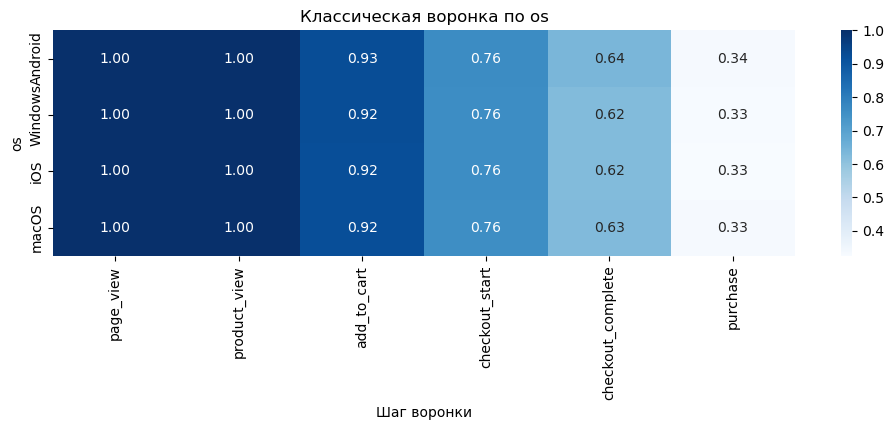

step,page_view,product_view,add_to_cart,checkout_start,checkout_complete,purchase
os,,,,,,
Android,1.0,0.998,0.926,0.762,0.637,0.335
Windows,1.0,0.999,0.924,0.760,0.625,0.329
iOS,1.0,0.999,0.922,0.759,0.625,0.325


In [24]:
# Добавляю ОС к заказам через таблицу событий
events_with_os = df_events.copy()
orders_with_os = df_orders.merge(
    df_events[['user_id', 'os']].drop_duplicates(subset='user_id'),
    on='user_id',
    how='left'
)

# Строю воронку по операционным системам
funnel_os_pivot = build_funnel(events_with_os, orders_with_os, steps, 'os')
display(funnel_os_pivot.head(3))


Конверсия почти не зависит от ОС до шага `checkout_complete`. На шаге `purchase` наблюдается заметное падение для всех платформ, особенно для мобильных Android и iOS. Windows и macOS показывают чуть меньшие дропы, но разница минимальна.

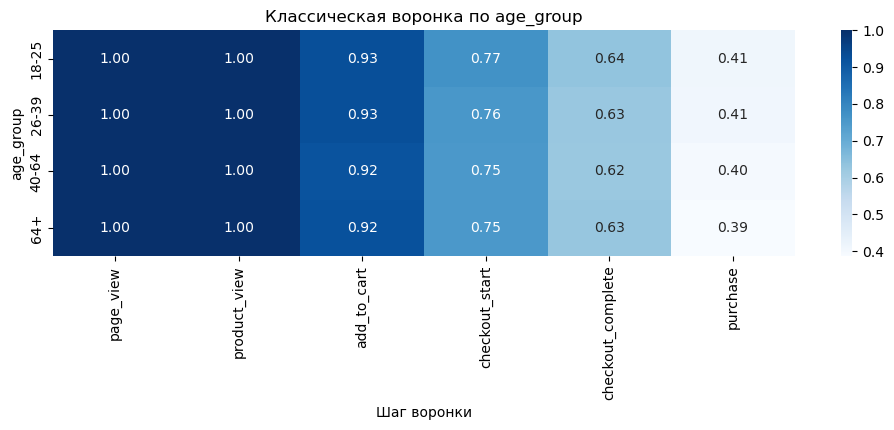

step,page_view,product_view,add_to_cart,checkout_start,checkout_complete,purchase
age_group,,,,,,
18-25,1.0,0.999,0.928,0.769,0.635,0.412
26-39,1.0,0.999,0.926,0.758,0.626,0.409
40-64,1.0,0.998,0.918,0.751,0.622,0.398


In [26]:
# Создаю возрастные группы
df_users_age = df_users.copy()
df_users_age['age_group'] = pd.cut(
    df_users_age['age'],
    bins=[0, 18, 25, 39, 64, 200],
    labels=['<18', '18-25', '26-39', '40-64', '64+'],
    right=False
).astype(str)

# Добавляю возрастную группу к событиям и заказам
events_with_age = df_events.merge(df_users_age[['user_id', 'age_group']], on='user_id', how='left')
orders_with_age = df_orders.merge(df_users_age[['user_id', 'age_group']], on='user_id', how='left')

# Строю воронку по возрастным группам
funnel_age_pivot = build_funnel(events_with_age, orders_with_age, steps, 'age_group')
display(funnel_age_pivot.head(3))


Группа <18 полностью отсутствует, что может указывать на нехватку данных или ограничение по возрасту. Наибольшая конверсия в покупку у молодых пользователей 18–25 лет, средние показатели у 26–39 лет, а старшие группы (40–64 и 64+) теряют больше пользователей на этапе checkout_complete. Основная часть потерь происходит между add_to_cart и checkout_start.

---

К сожалению, тут сегментация не показала каких-то инсайтов, так как по всем городам и на всех ОС данные имеют погрешности, а не значимую разницу в показателях.

---

На данном этапе невозможно однозначно утверждать, связано ли падение выручки исключительно со снижением конверсии в первую покупку. С учётом стабильного ARPPU и роста среднего чека, дополнительным фактором риска может быть низкий ретеншн пользователей и слабая повторная покупка. Для проверки этой гипотезы следующим шагом проанализирую retention по когортам.

cohort_index,0,1,2,3,4,5,6,7,8,9
first_order_month,,,,,,,,,,
2024-01-01,1.0,0.355,0.170,0.073,0.044,0.011,0.011,0.004,0.002,0.002
2024-02-01,1.0,0.307,0.137,0.056,0.031,0.018,0.004,NaN,NaN,NaN
2024-03-01,1.0,0.309,0.174,0.081,0.045,0.020,0.008,0.001,0.001,NaN


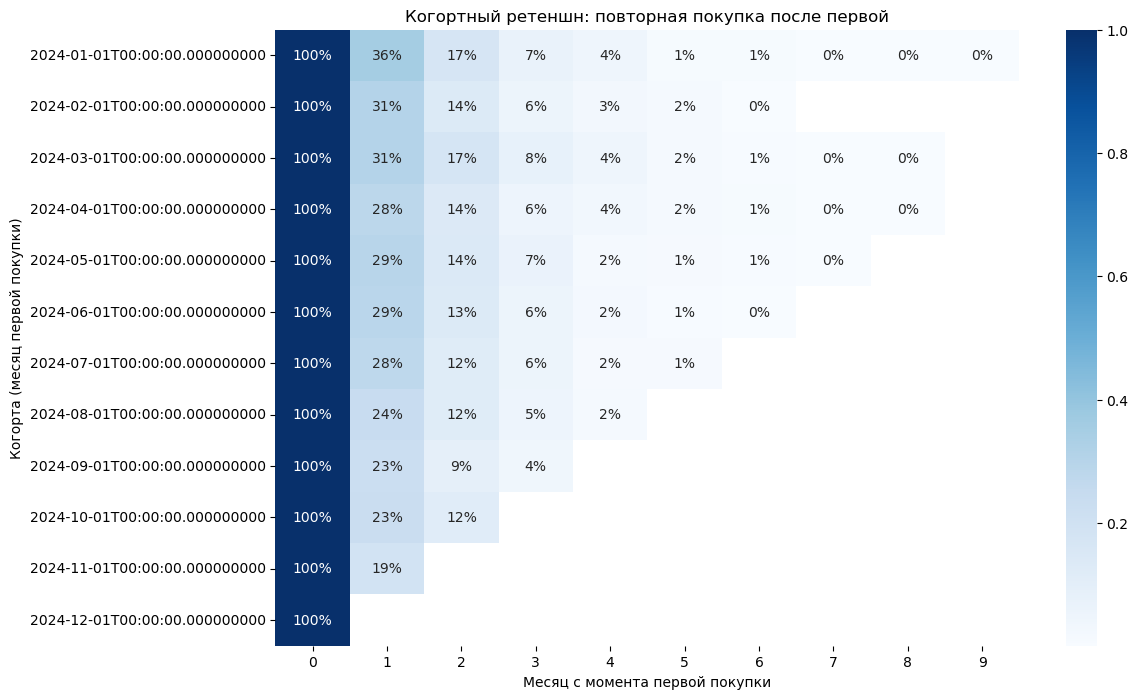

In [27]:
# Retention по когортам
# Нахожу месяц первой покупки для каждого пользователя
first_order = (
    df_orders
    .groupby('user_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'first_order_month'})
)

# Добавляю информацию о первой покупке в таблицу заказов
orders_with_cohort = df_orders.merge(first_order, on='user_id', how='left')

# Считаю номер месяца с момента первой покупки
orders_with_cohort['cohort_index'] = (
    (orders_with_cohort['order_month'].dt.year - orders_with_cohort['first_order_month'].dt.year) * 12 +
    (orders_with_cohort['order_month'].dt.month - orders_with_cohort['first_order_month'].dt.month)
)

# Считаю количество уникальных пользователей по когортам
cohort_data = (
    orders_with_cohort
    .groupby(['first_order_month', 'cohort_index'])['user_id']
    .nunique()
    .reset_index()
)

# Формирую когортную таблицу
cohort_pivot = cohort_data.pivot(
    index='first_order_month',
    columns='cohort_index',
    values='user_id'
)

# Считаю retention
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)

display(retention.head(3))

# Визуализация heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)

plt.title('Когортный ретеншн: повторная покупка после первой')
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Когорта (месяц первой покупки)')
plt.show()


Когортный анализ показал, что лишь 25–30% пользователей совершают повторную покупку в следующий месяц, а к третьему месяцу остаётся менее 10%. Для более поздних когорт ретеншн в первый месяц снижается, что говорит об ухудшении качества привлекаемой аудитории. Вместе с падением конверсии в покупку это приводит к снижению ARPU и общей выручки маркетплейса.

---

Проверю каналы привлечения.

cohort_index,0,1,2,3,4,5,6,7,8
acq_channel,,,,,,,,,
Affiliate,1.0,0.328,0.159,0.072,0.037,0.015,0.009,0.004,0.004
Email Marketing,1.0,0.141,0.094,0.038,0.028,0.028,0.026,NaN,NaN
Google Ads,1.0,0.291,0.146,0.065,0.031,0.016,0.007,0.003,0.002


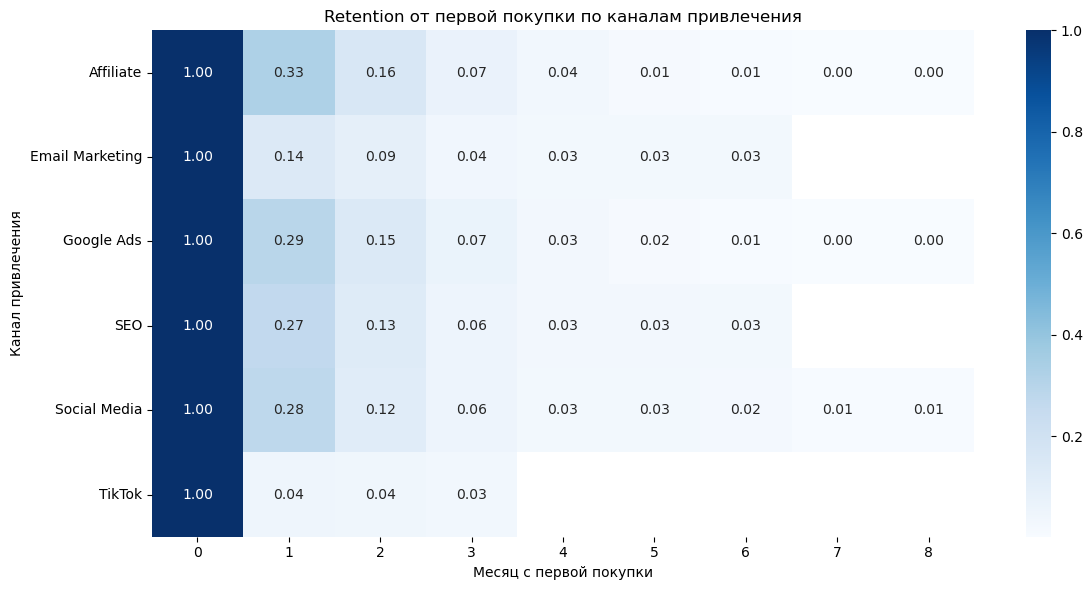

In [28]:
# Retention по каналам привлечения
df_orders_ret = df_orders.copy()

df_orders_ret['order_date'] = pd.to_datetime(df_orders_ret['order_date'])
df_orders_ret['order_month'] = df_orders_ret['order_date'].dt.to_period('M').dt.to_timestamp()

# Первый заказ пользователя 
first_order = (
    df_orders_ret
    .sort_values('order_date')
    .groupby('user_id', as_index=False)
    .first()[['user_id', 'order_month']]
    .rename(columns={'order_month': 'first_order_month'})
)

# Добавляю канал привлечения 
first_order = first_order.merge(
    df_users[['user_id', 'acq_channel']],
    on='user_id',
    how='left'
)

# Все заказы с первой покупкой 
orders_with_cohort = df_orders_ret.merge(
    first_order,
    on='user_id',
    how='left'
)

# Cohort (месяц с первой покупки)
orders_with_cohort['cohort_index'] = (
    (orders_with_cohort['order_month'].dt.year - orders_with_cohort['first_order_month'].dt.year) * 12
    + (orders_with_cohort['order_month'].dt.month - orders_with_cohort['first_order_month'].dt.month)
)

# Количество пользователей по каналам и cohort_index 
retention = (
    orders_with_cohort
    .groupby(['acq_channel', 'first_order_month', 'cohort_index'])['user_id']
    .nunique()
    .reset_index()
)

# Размер когорт
cohort_size = (
    retention[retention['cohort_index'] == 0]
    .set_index(['acq_channel', 'first_order_month'])['user_id']
)

# Расчёт retention 
retention['retention'] = retention.apply(
    lambda row: row['user_id'] / cohort_size.loc[(row['acq_channel'], row['first_order_month'])],
    axis=1
)

# Агрегация: средний retention по каналам  
retention_channel = (
    retention
    .groupby(['acq_channel', 'cohort_index'])['retention']
    .mean()
    .reset_index()
)

retention_pivot = (
    retention_channel
    .pivot(index='acq_channel', columns='cohort_index', values='retention')
    .round(3)
)

display(retention_pivot.head(3))

# Тепловая карта 
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention_pivot,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title('Retention от первой покупки по каналам привлечения')
plt.xlabel('Месяц с первой покупки')
plt.ylabel('Канал привлечения')
plt.tight_layout()
plt.show()


Ретеншн сильно различается по каналам: Affiliate, Google Ads, SEO и Social Media показывают повторные покупки у 15–30% пользователей в следующий месяц, Email Marketing хуже (10–15%), а TikTok почти не удерживает пользователей. Основная часть аудитории делает только первую покупку, повторные редки.

---

Проверю, что происходит с каналами по другим метрикам. 

,spend_month,acq_channel,budget,acquired_users,cac
0,2024-01-01,Affiliate,179343.38750,575.0,311.901543
1,2024-01-01,Direct,11890.80375,NaN,NaN
2,2024-01-01,Email Marketing,44263.61250,175.0,252.934929


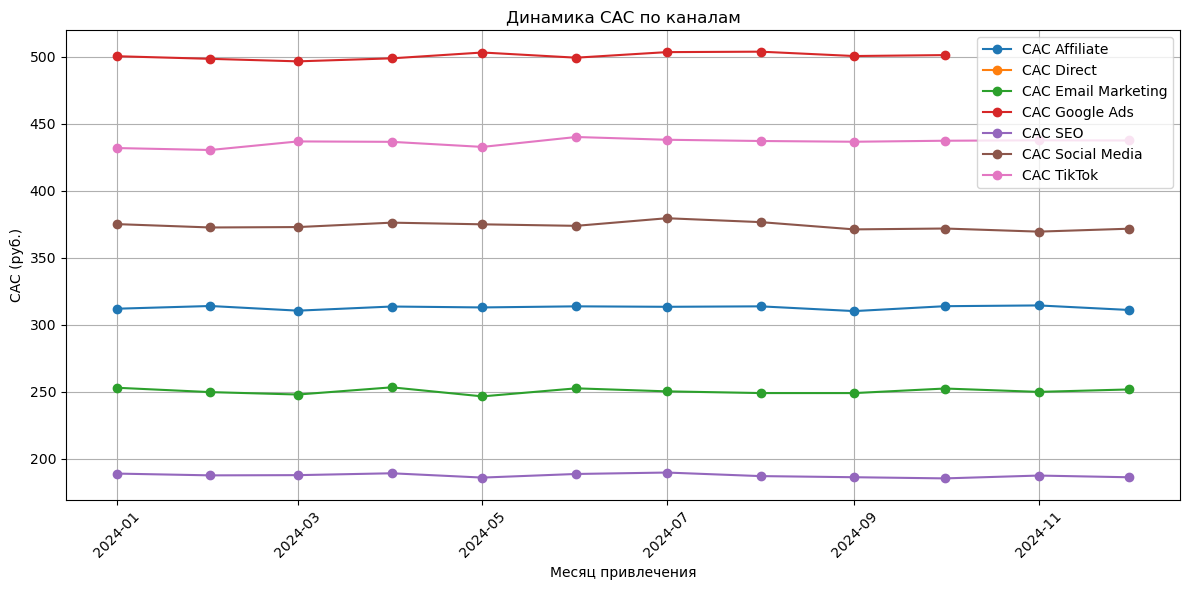

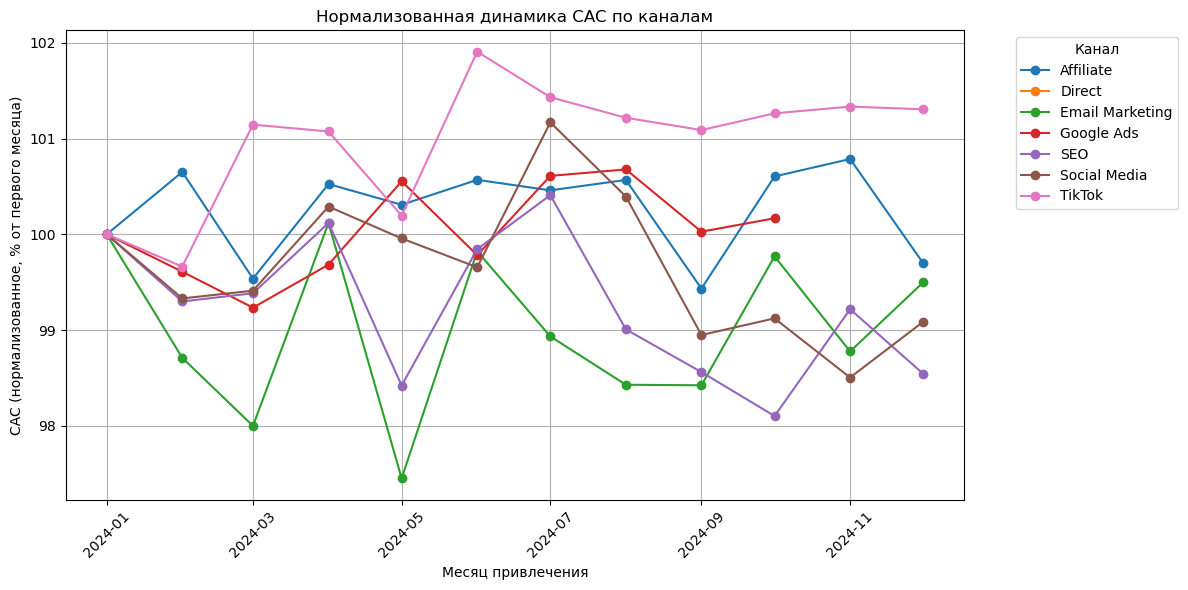

In [44]:
# CAC
cac_df = (
    df_camp
    .groupby(['spend_month', 'acq_channel'], as_index=False)
    .agg(budget=('budget','sum'))
    .merge(
        df_users.groupby(['cohort_month','acq_channel'], as_index=False)
        .agg(acquired_users=('user_id','nunique'))
        .rename(columns={'cohort_month':'spend_month'}),
        on=['spend_month','acq_channel'], how='left'
    )
)
cac_df['cac'] = cac_df['budget'] / cac_df['acquired_users']


display(cac_df.head(3))

# Строю график
plt.figure(figsize=(12,6))

# Список каналов
channels = cac_df['acq_channel'].unique()

for channel in channels:
    df_ch = cac_df[cac_df['acq_channel'] == channel]
    plt.plot(df_ch['spend_month'], df_ch['cac'], marker='o', label=f'CAC {channel}')

plt.title('Динамика CAC по каналам')
plt.xlabel('Месяц привлечения')
plt.ylabel('CAC (руб.)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# Копия для визуализации
viz_df = cac_df.copy()

# Нормализация CAC по каждому каналу к первому месяцу
viz_df['cac_norm'] = viz_df.groupby('acq_channel')['cac'].transform(lambda x: x / x.iloc[0] * 100)

# Размер графика
plt.figure(figsize=(12,6))

channels = viz_df['acq_channel'].unique()

# Линии CAC (нормализованные) по каналам
for channel in channels:
    df_ch = viz_df[viz_df['acq_channel'] == channel]
    plt.plot(df_ch['spend_month'], df_ch['cac_norm'], marker='o', label=f'{channel}')

# Настройки графика
plt.title('Нормализованная динамика CAC по каналам')
plt.xlabel('Месяц привлечения')
plt.ylabel('CAC (нормализованное, % от первого месяца)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Для большинства каналов (Affiliate, Email, SEO, Social Media, TikTok, Google Ads) CAC стабильный в пределах ±5% от среднего значения по году.

- Google Ads и TikTok — самые дорогие каналы, их CAC выше всех остальных.

- SEO, Email, Affiliate — относительно дешёвые каналы, стабильные по месяцам.

---

Дальше смотрю `ROI`.

Upd: ROI у `Direct` был слишком большим из-за низкого бюджета, что сильно искажало визуализацию других каналов; при этом на общий вклад в маркетинг он почти не влияет.


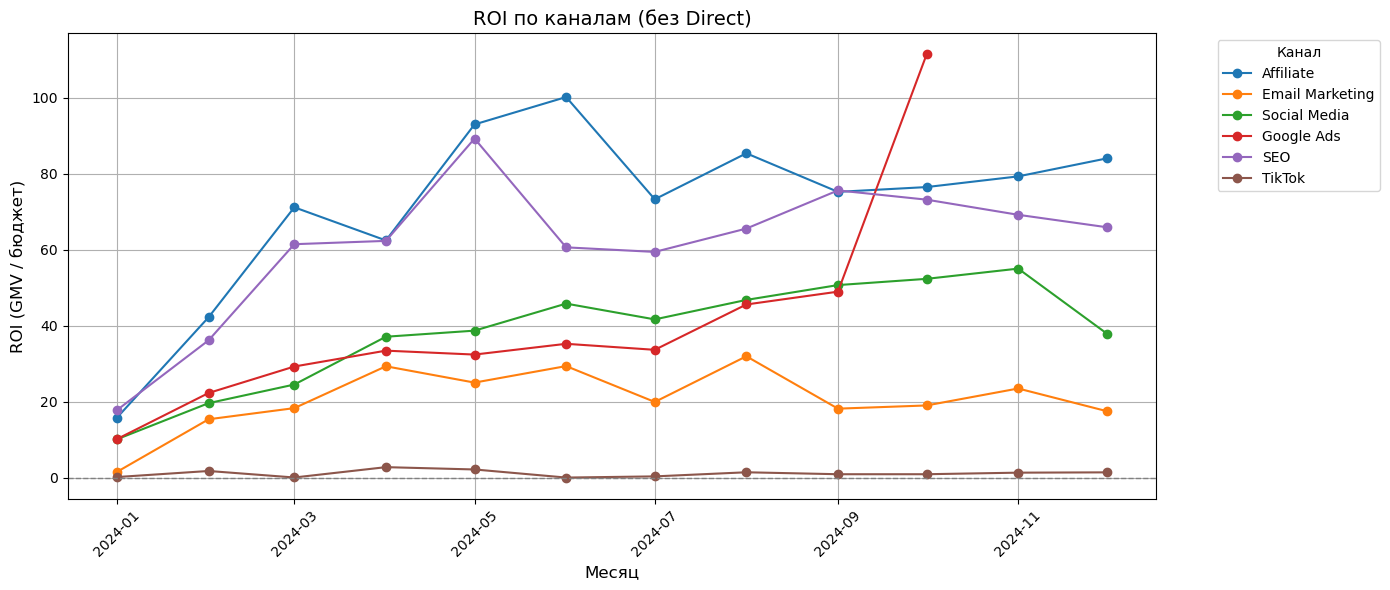

In [30]:
# ROI по каналам: GMV от пользователей канала vs. бюджет канала
# Привязываю GMV к каналу через пользователей

# GMV по каждому заказу с каналом привлечения пользователя
orders_with_channel = df_orders.merge(
    df_users[['user_id', 'acq_channel']],
    on='user_id',
    how='left'
)

gmv_by_channel = (
    orders_with_channel
    .groupby(['order_month', 'acq_channel'])['total_price']
    .sum()
    .reset_index()
    .rename(columns={'total_price': 'GMV', 'order_month': 'spend_month'})
)

roi_channel_df = df_camp.merge(
    gmv_by_channel,
    on=['spend_month', 'acq_channel'],
    how='left'
)

roi_channel_df = roi_channel_df.dropna(subset=['GMV', 'budget']).copy()

# ROI = (GMV - бюджет) / бюджет
roi_channel_df['roi'] = ((roi_channel_df['GMV'] - roi_channel_df['budget']) / roi_channel_df['budget']).round(2)

# Исключаю Direct: бюджет практически нулевой, ROI нерепрезентативен
roi_channel_df = roi_channel_df[roi_channel_df['acq_channel'] != 'Direct']

# Строю график ROI по каналам
plt.figure(figsize=(14, 6))
for channel in roi_channel_df['acq_channel'].unique():
    df_ch = roi_channel_df[roi_channel_df['acq_channel'] == channel]
    plt.plot(df_ch['spend_month'], df_ch['roi'], marker='o', label=channel)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('ROI по каналам (без Direct)', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('ROI (GMV / бюджет)', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Самый высокий и устойчивый ROI показывают Direct, Email Marketing и SEO — эффективность растёт в первой половине года и остаётся высокой до осени, с умеренным снижением к концу года.

Affiliate и Social Media — средний, но стабильный ROI без резких провалов.

В октябре у Google ROI резко подскочил вверх, а затем данные оборвались. Это может быть связано с какой-то кратковременной акцией/технической ошибкой или это может быть связано с санкциями и уходом некоторых западных компаний из РФ. 

TikTok — наименее эффективный канал: у него наблюдается резкое ухудшение ROI во второй половине года вплоть до отрицательных значений.

---

Теперь посмотрю воронку по каналам привлечения.

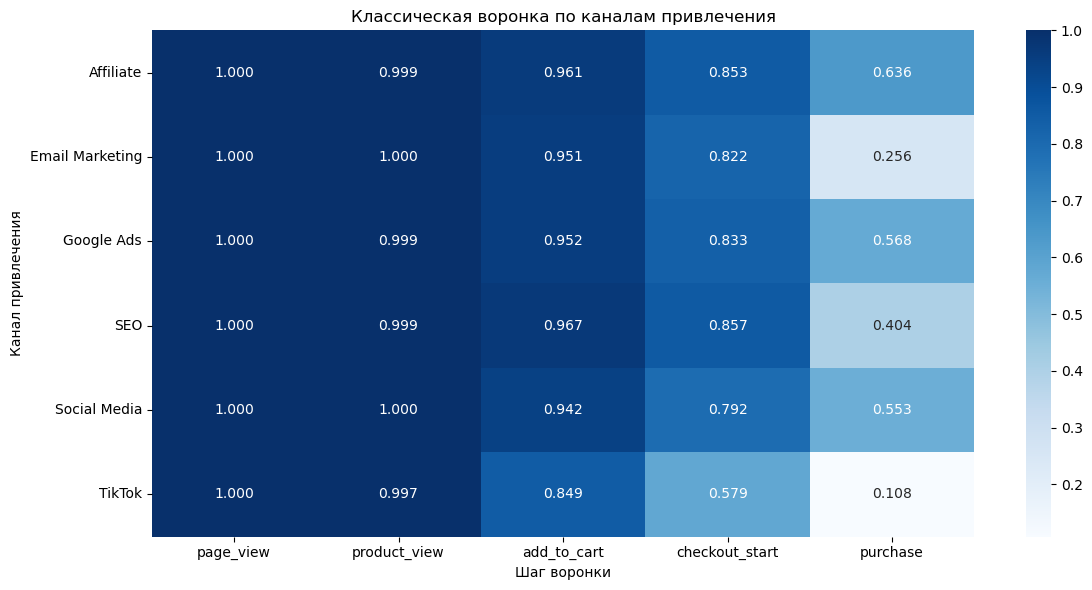

In [31]:
# Воронка по каналам привлечения
# Создаю DataFrame по каналам
funnel_channel = (
    df_events[df_events['event_type'].isin(events_steps)]
    .merge(df_users[['user_id', 'acq_channel']], on='user_id', how='left')
    .groupby(['acq_channel', 'event_type'])['user_id']
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=events_steps[:-1])
)

# Добавляю шаг purchase
purchase_channel = (
    df_orders.merge(df_users[['user_id','acq_channel']], on='user_id', how='left')
    .groupby('acq_channel')['user_id']
    .nunique()
)

funnel_channel['purchase'] = purchase_channel

# Классическая конверсия 
funnel_channel_conv = funnel_channel.div(funnel_channel['page_view'], axis=0)


#  Вывод таблицы 

#  Хитмап 
plt.figure(figsize=(12,6))
sns.heatmap(
    funnel_channel_conv,
    annot=True,
    fmt='.3f',
    cmap='Blues'
)
plt.title('Классическая воронка по каналам привлечения')
plt.xlabel('Шаг воронки')
plt.ylabel('Канал привлечения')
plt.tight_layout()
plt.show()


Воронка показывает, что для большинства каналов конверсия от просмотра к добавлению в корзину и далее до начала оформления заказа держится на хорошем уровне (Affiliate, SEO, Google Ads), однако у TikTok и Email Marketing наблюдаются явные узкие места: TikTok теряет пользователей уже на этапе add_to_cart и checkout_start, а Email Marketing — на этапе покупки (purchase).

---

Далее посмотрю, что происходит с категориями товаров

In [32]:
#  Группирую по категории 
metrics = df_orders.groupby('category_name').agg(
    revenue=('total_price', lambda x: x.sum() * 0.05),
    orders=('order_id', 'count'),
    avg_order=('total_price', 'mean')
).sort_values('revenue', ascending=False)

#  Топ-5 по выручке 
top10 = metrics.head()

#  Антитоп-5 по выручке (ниже среднего) 
rev_mean = metrics['revenue'].mean()
anti10 = metrics[metrics['revenue'] < rev_mean].sort_values('revenue').head()

#  Вывод 
print("ТОП-10 категорий по выручке:")
for i, row in top10.iterrows():
    display(Markdown(f'**{i}**: выручка={row.revenue:.0f}, заказов={row.orders}, средний чек={row.avg_order:.0f}'))

print("\nАНТИТOП-10 категорий (выручка ниже среднего):")
for i, row in anti10.iterrows():
    display(Markdown(f'**{i}**: выручка={row.revenue:.0f}, заказов={row.orders}, средний чек={row.avg_order:.0f}'))


ТОП-10 категорий по выручке:


**Мебель для дома**: выручка=3580998, заказов=979.0, средний чек=73156

**Бытовая техника**: выручка=2248933, заказов=1030.0, средний чек=43669

**Украшения и часы**: выручка=1718297, заказов=1024.0, средний чек=33560

**Спортивный инвентарь**: выручка=1165361, заказов=1000.0, средний чек=23307

...

**Средства для ухода**: выручка=163270, заказов=1172.0, средний чек=2786

**Книги и канцтовары**: выручка=204443, заказов=1316.0, средний чек=3107

**Детская одежда**: выручка=321305, заказов=1421.0, средний чек=4522

**Медицинские товары**: выручка=341083, заказов=980.0, средний чек=6961

**Зоотовары**: выручка=372584, заказов=1396.0, средний чек=5338

ТОП-5 категорий по выручке приносит основную долю выручки, и здесь высокий средний чек указывает на более дорогие товары.

Антитоп-5 категорий. Несмотря на высокое число заказов, выручка низкая из-за низкого среднего чека.

Инсайты: высокие продажи не всегда совпадают с высокой выручкой — категории с большим числом заказов, но низким средним чеком вносят мало в общий доход. Это сразу видно при сравнении топов и антитопов.

---

Так же проверю сегменты покупателей.

,buyer_segment,order_month,revenue,orders,users
0,medium,2024-01-01,3855353.88,258,170
1,medium,2024-02-01,6866335.35,503,326
2,medium,2024-03-01,8418235.77,669,438


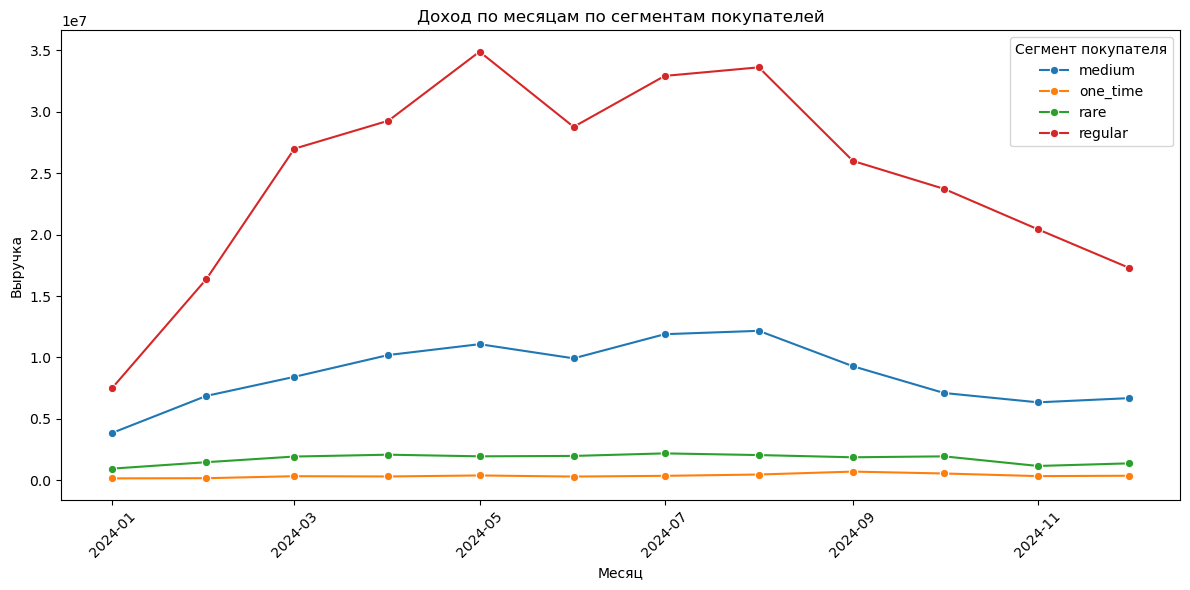

In [33]:
# Объединяю заказы с сегментом покупателя 
orders_with_segment = df_orders.merge(
    df_users[['user_id', 'buyer_segment']],
    on='user_id',
    how='left'
)

# Доход по сегментам и месяцам
revenue_by_segment = (
    orders_with_segment
    .groupby(['buyer_segment', 'order_month'])
    .agg(
        revenue=('total_price', 'sum'),
        orders=('order_id', 'nunique'),
        users=('user_id', 'nunique')
    )
    .reset_index()
    .sort_values(['buyer_segment', 'order_month'])
)

display(revenue_by_segment.head(3))

# График
plt.figure(figsize=(12,6))
sns.lineplot(
    data=revenue_by_segment,
    x='order_month',
    y='revenue',
    hue='buyer_segment',
    marker='o'
)


plt.title('Доход по месяцам по сегментам покупателей')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.legend(title='Сегмент покупателя')
plt.tight_layout()
plt.show()

Сегмент regular приносит наибольшую выручку и растёт до пиковых значений в мае–августе, после чего наблюдается постепенное снижение к концу года.

Сегмент medium демонстрирует стабильный рост до августа, но затем доход заметно падает, при этом показатели по пользователям и заказам коррелируют с выручкой.

Сегменты rare и one_time приносят относительно небольшой доход; у one_time виден очень ограниченный рост и значительные колебания между месяцами, что указывает на нерегулярность покупок.

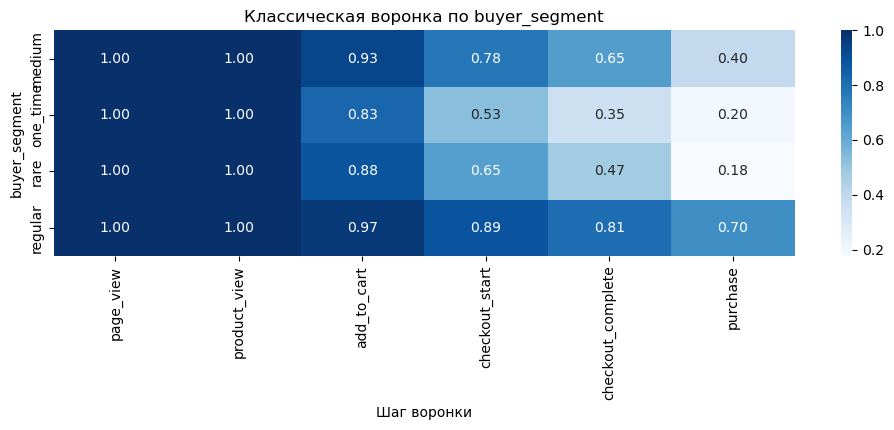

step,page_view,product_view,add_to_cart,checkout_start,checkout_complete,purchase
buyer_segment,,,,,,
medium,1.0,0.999,0.932,0.777,0.651,0.395
one_time,1.0,0.998,0.828,0.529,0.351,0.199
rare,1.0,0.997,0.883,0.646,0.473,0.177


In [34]:
# Добавляю сегмент покупателя к событиям
events_with_segment = df_events.merge(df_users[['user_id', 'buyer_segment']], on='user_id', how='left')

# Строю воронку по сегментам покупателей
# orders_with_segment уже создан в ячейке выше
funnel_segment_pivot = build_funnel(events_with_segment, orders_with_segment, steps, 'buyer_segment')
display(funnel_segment_pivot.head(3))


Сегмент regular (5326 человек) показывает наилучшую конверсию по всем шагам, финальная покупка достигает 70% от начала пути.

Сегмент medium теряет значительное число пользователей на этапе checkout - purchase (конверсия 39%), что ограничивает доход сегмента. Так же в этом сегменте наибольшее число пользователей 9353 на этапе просмотра страницы.

Сегменты rare и one_time имеют критические потери на финальном этапе, конверсия покупки 18–20%, что объясняет их низкий вклад в общую выручку. Однако в Rare сегменте 5589 пользователей, что является большим процентом, поэтому на них стоит обратить внимание.  

В сегменте one_time 1294 человек. С ними тоже можно работать, но это принесет меньше выгоды.

---


## Выводы по этапу 4

**Итоговый аналитический вывод**

---

**1. Общая воронка пользователей**  
Анализ верхнеуровневой воронки показал, что потери пользователей минимальны на первых шагах (page_view - product_view), но основные оттоки начинаются после добавления товара в корзину. Самый критичный этап — переход от завершения оформления заказа (checkout_complete) к покупке: до оплаты доходит лишь 40–64% пользователей, в зависимости от сегмента. Итоговая конверсия в покупку от первого шага составляет около 40%.  

---

**2. Сегментация по регионам, ОС и возрасту**  
- **Регионы:** конверсия в целом одинакова, небольшие различия на шаге покупки — немного выше у Нижнего Новгорода и Краснодара, ниже у Новосибирска и Московской области.  
- **Операционные системы:** различия минимальны, падение конверсии на этапе покупки примерно одинаковое для всех платформ.  
- **Возрастные группы:** максимальная конверсия у пользователей 18–25 лет; средние показатели у 26–39; старшие группы теряют больше на этапе checkout_complete. Группа <18 отсутствует, что указывает на ограниченность данных.  

**Вывод**: сегментации по этим признакам не выявили значимых инсайтов, показатели очень похожи.  

---


**3. Сегментация по buyer_segment и доход по месяцам**  
- **Сегменты:** regular — приносят наибольший доход, medium — средний, rare — умеренный, one_time — минимальный.  
- Доход по месяцам показывает устойчивый рост у регулярных покупателей в первой половине года с пиком в августе, затем наблюдается снижение к концу года. Medium и rare сегменты демонстрируют схожие тренды, one_time — небольшой и нестабильный доход.  

**Вывод:** фокус на regular и medium сегментах обеспечивает стабильный доход, Rare сегмент требует внимания к удержанию и повторным покупкам.  

---


**4. Воронка по сегментам покупателей**  
- **Regular:** конверсия от просмотра до покупки 70%, падение на финальных шагах минимальное.  
- **Medium:** конверсия 40%, значительное падение между checkout_complete - purchase.  
- **Rare:** конверсия 37%, основной дроп на этапе checkout_start - checkout_complete.  
- **One_time:** конверсия всего 20%, критические потери уже после add_to_cart.  

**Вывод:** сегментация воронки подтверждает, что регулярные покупатели наиболее ценны, Rare  проблемный сегмент, требующий работы по удержанию и стимуляции повторных покупок.  

---


**5. Retention и когортный анализ**  
Повторные покупки совершают только 25–30% пользователей в первый месяц, к третьему месяцу остаётся менее 10%. Ретеншн новых когорт падает, что говорит о снижении качества привлеченной аудитории. Низкий ретеншн совместно с падением конверсии к покупке объясняет снижение ARPU и общей выручки маркетплейса.  

---


**6. Каналы привлечения и ROI**  
- **Эффективные каналы:** Direct, Email Marketing, SEO - высокий и стабильный ROI, особенно в первой половине года.  
- **Средние:** Affiliate и Social Media - ROI средний, без резких изменений.  
- **Проблемные каналы:** TikTok - резкое падение ROI и ретеншн; Email Marketing — слабый переход к покупке.  
- **CAC:** Google Ads и TikTok - самые дорогие, SEO, Email и Affiliate — дешевые и стабильные.  

**Вывод:** TikTok и частично Email требуют детального изучения, другие каналы работают относительно стабильно.  

---


**7. Воронка по каналам**  
Анализ воронки показал узкие места для **TikTok** (от add_to_cart до checkout_start) и **Email Marketing** (от checkout_complete до purchase). Остальные каналы держат высокую конверсию на первых шагах, падение более умеренное.  

---


**8. Категории товаров**  
- **ТОП-10 по выручке:** Мебель для дома, Бытовая техника, Украшения и часы, Спортивный инвентарь, Товары для туризма и др.  
- **Антитоп-10:** Средства для ухода, Книги и канцтовары, Детская одежда, Медицинские товары, Зоотовары.  

**Вывод:** самые дорогие и крупные покупки приносят максимальную выручку, низкоценовые категории - мало. Средний чек топов значительно выше антитопов, что прямо влияет на доходность.  

---


**9. Общие инсайты и точки роста**  
1. Основные потери пользователей происходят между **add_to_cart - checkout_start - purchase**.  
2. **Низкий ретеншн** и слабая повторная покупка ограничивают рост выручки, особенно для **TikTok**.  
3. Сегментация по **buyer_segment** выявила, что регулярные покупатели приносят основной доход; Rare сегмент требует работы по улучшению конверсии.  
4. Категории товаров с высоким средним чеком обеспечивают основной доход, низкодоходные категории можно пересмотреть или оптимизировать.
5. Возможности роста: стимуляция повторных покупок в one_time и rare сегментах, персонализация предложений для высокодоходных сегментов, улучшение UX на этапе checkout.

---



**Гипотезы**

Из перечисленных гипотез команда приоритизировала проверку влияния финансового стимула на конверсию TikTok-пользователей — как наиболее быстро проверяемую и с наибольшим потенциальным эффектом на выручку. Этот эксперимент описан в разделе 5.

---

1. **Оптимизация процесса оплаты**

Гипотеза: Упрощение оформления заказа (один клик или гостевой доступ) повысит конверсию на этапе checkout_complete - purchase.

Обоснование: Воронка показала, что именно этот этап теряет до 36% пользователей, падение наблюдается во всех каналах.



2. **Работа с проблемным каналом** (TikTok)

Гипотеза: Перераспределение части бюджета с TikTok на канал с более высокой конверсией (Affiliate) увеличит общую выручку и ROI.

Обоснование: TikTok теряет пользователей на ранних этапах, конверсия почти в 6 раз ниже, ROI низкий.



3. **Оптимизация для категорий с высоким средним чеком**

Гипотеза: Акцент на продвижение товаров из ТОП-10 категорий с высоким средним чеком увеличит выручку и ARPU.

Обоснование: Анализ показал, что доход в основном формируется за счет нескольких категорий, менее доходные категории приносят мало.


4. **Увеличение конверсии Rare сегмента**

Гипотеза: если добавить навигацию и подсказки по оформлению заказа для этого сегмента, конверсия на финальных шагах вырастет на 10–12%.

Обоснование: Пользователей из Rare сегмента  начинают оформление, но не завершают его - нужно уменьшить трение, так как конверсия до покупки 37%, основной дроп между checkout_start - checkout_complete.


5. **Увеличение конверсии Medium и Regular сегментов**

Гипотеза: если предложить персонализированные предложения и cross-sell для регулярных покупателей в низкий сезон, доход в эти месяцы повысится на 5–10%.

Обоснование: сегменты приносят основной доход, и стимулы могут сгладить сезонные колебания.

## 5. A/B-тест: бонус на первую покупку для TikTok-пользователей

## Контекст эксперимента

По итогам анализа команда продукта приняла решение проверить гипотезу о влиянии финансового стимула на конверсию TikTok-пользователей. Дизайн-документ был подготовлен параллельно; ниже — проведение эксперимента и интерпретация результатов.

## Новые данные

```python
pa_diploma_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv')
pa_diploma_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv')
pa_diploma_sessions_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv')
pa_diploma_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv')
```

## Результаты сплита

```python
pa_diploma_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')
```

- `user_id` — id пользователя
- `group` — группа (control / treatment)

Таблицы пользователей, событий и заказов идентичны историческим.

## Описание таблицы `sessions_AB`

| Поле | Описание |
|------|----------|
| `session_id` | Уникальный идентификатор сессии |
| `user_id` | Уникальный идентификатор пользователя |
| `session_start` | Дата и время начала сессии |
| `os` | Операционная система |
| `device` | Тип устройства |
| `region` | Регион пользователя |
| `browser` | Браузер |
| `country` | Страна |
| `entry_path` | Начальная страница сессии |
| `screen_size` | Разрешение экрана |
| `scroll_depth` | Глубина прокрутки |
| `user_segment` | Сегмент пользователя |
| `utm_campaign_id` | Идентификатор рекламной кампании |
| `session_week` | Неделя сессии |
| `session_month` | Месяц сессии |

## Дизайн эксперимента: бонус на первую покупку для пользователей TikTok

### 1. Контекст и цель

- **Бизнес-контекст:** TikTok показывает низкий retention и слабую конверсию в покупку. Для стимулирования первой покупки новым пользователям предоставляется бонус.
- **Цель:** Проверить, влияет ли бонус на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку увеличит конверсию в первую покупку.

---

### 2. Формат

- **Тип:** rolling split
- **Канал:** только пользователи TikTok
- **Группы:** контроль (без бонуса) и тест (с бонусом)
- **Распределение:** равномерное по дате регистрации
- **Период:** 3 недели

---

### 3. Метрики

**Основная:** конверсия в первую покупку — целевой рост в тестовой группе.

**Вспомогательные:** ARPU, ARPPU, AOV.

**Барьерная:** общая выручка от пользователей TikTok.

---

### 4. Размер выборки

Размер групп определяется фактическим трафиком TikTok за период. Расчёт мощности и MDE не проводился из-за срочности задачи.


In [35]:
# Загружаю данные

df_users_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv', 
                      parse_dates=['registration_date', 'cohort_week', 'cohort_month'])

df_split_us_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')

df_events_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv', 
                      parse_dates=['event_date', 'event_week', 'event_month'])

df_orders_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv', 
                      parse_dates=['order_date', 'order_week','order_month'])

df_sess_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv', 
                      parse_dates=['session_start', 'session_week', 'session_month'])


In [36]:
# Смотрю основную информацию по каждому датасету
display(Markdown('**Пользователи**'))
#df_users_ab.info()
display(df_users_ab.head(1))
display(Markdown("---"))

display(Markdown('**Разделенные пользователи**'))
#df_split_us_ab.info()
display(df_split_us_ab.head(1))
display(Markdown("---"))

display(Markdown('**События**'))
#df_events_ab.info()
display(df_events_ab.head(1))
display(Markdown("---"))

display(Markdown('**Заказы**'))
#df_orders_ab.info()
display(df_orders_ab.head(1))
display(Markdown("---"))

display(Markdown('**Сессии**'))
#df_sess_ab.info()
display(df_sess_ab.head(1))

**Пользователи**

,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,Android,49,mobile,M,Екатеринбург,Edge,Россия,TikTok,10.0,спящий,one_time,2024-01-01,2024-01-01


---

**Разделенные пользователи**

,user_id,group
0,44965,control


...

**Заказы**

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01


---

**Сессии**

,session_id,user_id,session_start,os,device,region,browser,country,entry_path,path_start,utm_source,screen_size,scroll_depth,user_segment,utm_campaign_id,session_week,session_month
0,705,160,2024-01-12 02:30:37.000,Windows,mobile,Москва,Safari,Россия,/home,/recommend/10,unknown,768x1024,51,regular,14.0,2024-01-08,2024-01-01


In [37]:
# Проверяю, что user_id только в одной группе
dup = df_split_us_ab.groupby('user_id')['group'].nunique()
print('Пользователи в двух группах:', (dup > 1).sum())

# Беру только TikTok и объединяю со сплитом
users = (
    df_users_ab[df_users_ab['acq_channel'] == 'TikTok']
    .merge(df_split_us_ab[['user_id','group']], on='user_id', how='inner')
    .copy()
)

# Исключаю пользователей с покупками до регистрации
orders_reg = df_orders_ab.merge(
    users[['user_id','registration_date']],
    on='user_id',
    how='inner'
)

bad_users = orders_reg[
    orders_reg['order_date'] < orders_reg['registration_date']
]['user_id'].unique()

df_users_final = users[~users['user_id'].isin(bad_users)].copy()

print('\nРазмер финальной выборки:', df_users_final['user_id'].nunique())
print(df_users_final['group'].value_counts())
print('\nПропорции распределения финальной выборки:')
print(df_users_final['group'].value_counts(normalize=True).round(3))




# Проверяю период регистрации
exp_start = df_users_final['registration_date'].min()
exp_end = df_users_final['registration_date'].max()
print('\nПериод эксперимента:', exp_start, '-', exp_end)
print('Длительность, дней:', (exp_end - exp_start).days)


Пользователи в двух группах: 0

Размер финальной выборки: 2968
group
control      1503
treatment    1465
Name: count, dtype: int64

Пропорции распределения финальной выборки:
group
control      0.506
treatment    0.494
Name: proportion, dtype: float64

Период эксперимента: 2025-01-01 00:05:00 - 2025-01-26 23:41:00
Длительность, дней: 25


В анализе участвуют 2 968 пользователей TikTok, корректно распределённых между группами control (1503) и treatment (1465), баланс групп соблюдён.
Период эксперимента — январь 2025 года. Пользователей с покупками до регистрации не выявлено, выборка очищена корректно.

---

Проверяю распределение пользователей по ключевым сегментам.

region,Другие регионы,Екатеринбург,Краснодар,Москва,Московская область,Нижний Новгород,Новосибирск,Ростов-на-Дону,Санкт-Петербург
group,,,,,,,,,
control,487,68,63,371,115,65,65,39,230
treatment,494,72,46,359,120,59,50,45,220


os,Android,Windows,iOS,macOS
group,,,,
control,369,358,401,375
treatment,339,366,375,385


buyer_segment,medium,one_time,rare,regular
group,,,,
control,539,215,456,293
treatment,530,246,431,258


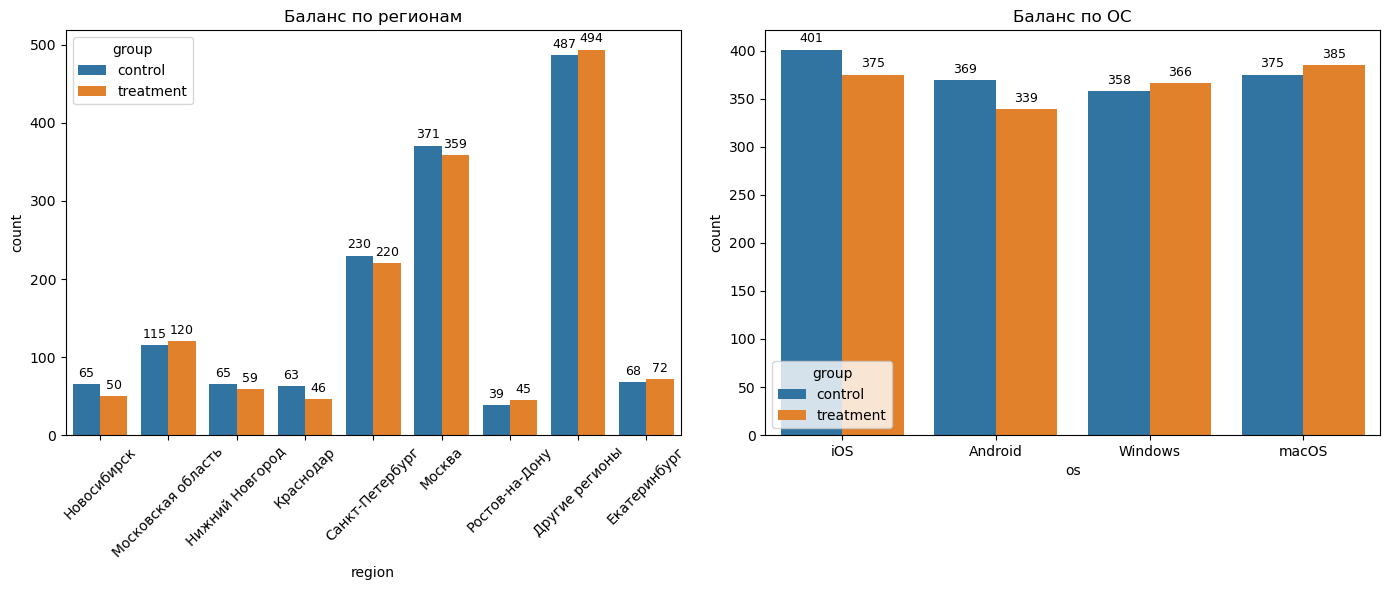

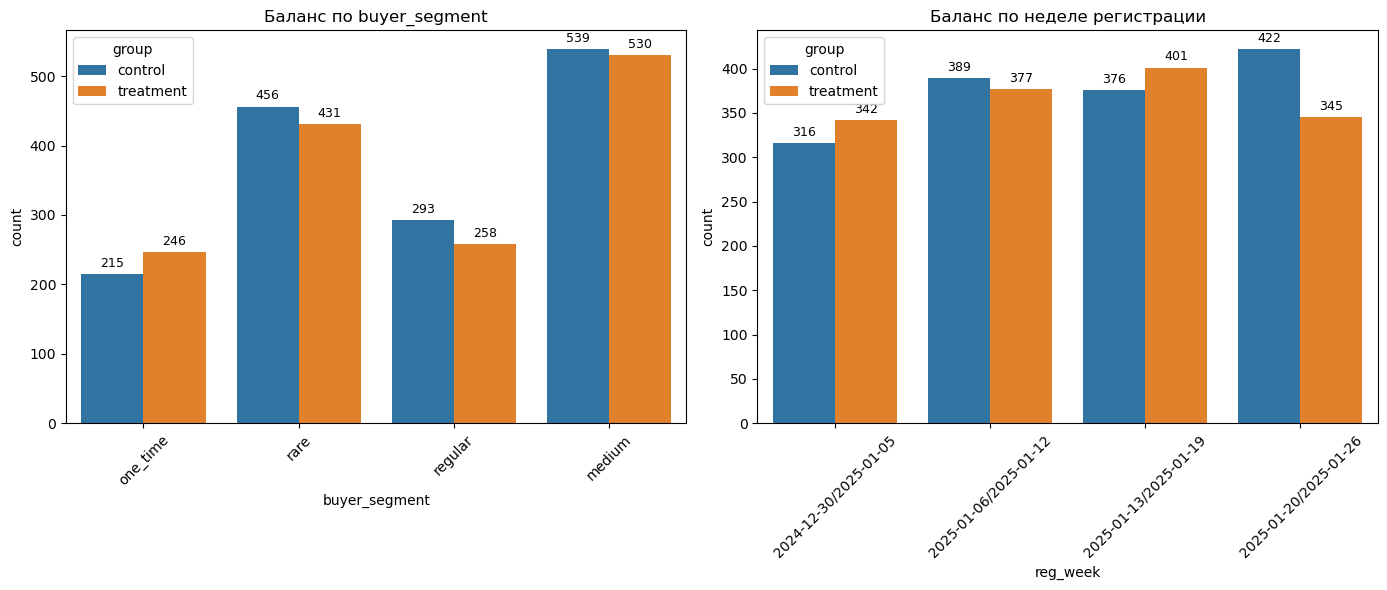

In [38]:
# Проверяю баланс по ключевым сегментам
display(
    df_users_final.groupby(['group','region'])['user_id']
    .nunique()
    .unstack(fill_value=0)
)

display(
    df_users_final.groupby(['group','os'])['user_id']
    .nunique()
    .unstack(fill_value=0)
)

display(
    df_users_final.groupby(['group','buyer_segment'])['user_id']
    .nunique()
    .unstack(fill_value=0)
)

# Визуализация
# Баланс по регионам и ОС
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
ax1 = sns.countplot(data=df_users_final, x='region', hue='group')
plt.title('Баланс по регионам')
plt.xticks(rotation=45)
add_labels(ax1)

plt.subplot(1,2,2)
ax2 = sns.countplot(data=df_users_final, x='os', hue='group')
plt.title('Баланс по ОС')
add_labels(ax2)

plt.tight_layout()
plt.show()


# Баланс по buyer_segment и неделе регистрации
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
ax3 = sns.countplot(data=df_users_final, x='buyer_segment', hue='group')
plt.title('Баланс по buyer_segment')
plt.xticks(rotation=45)
add_labels(ax3)

df_users_final['reg_week'] = (
    df_users_final['registration_date']
    .dt.to_period('W')
    .astype(str)
)

plt.subplot(1,2,2)
ax4 = sns.countplot(data=df_users_final, x='reg_week', hue='group')
plt.title('Баланс по неделе регистрации')
plt.xticks(rotation=45)
add_labels(ax4)

plt.tight_layout()
plt.show()

Распределение пользователей между control и treatment по регионам, ОС и buyer_segment в целом сбалансировано: в большинстве категорий доли близки к 50/50, существенных перекосов не наблюдается. Небольшие отклонения есть в отдельных регионах (Краснодар, Новосибирск) и сегменте one_time, но они не критичны.

По неделям регистрации группы также распределены равномерно, хотя в последнюю неделю наблюдается смещение в сторону control (55% против 45%). В целом рандомизация выглядит корректной, серьёзных системных перекосов не выявлено.

---

Далее проверяю время первой покупки, чтобы она была в пределах 3-недельного окна эксперимента и считаю основные метрики.

Доля платящих по группам:
group
control      0.009315
treatment    0.075085
Name: first_purchase_flag, dtype: float64


,group,users_total,users_paying,conversion,ARPU,ARPPU,AOV,total_revenue,conversion_uplift_%
0,control,1503,14,0.009315,233.269654,25043.163571,15936.558636,350604.29,0.000000
1,treatment,1465,110,0.075085,2624.980908,34959.973000,16647.606190,3845597.03,706.094588


,group,count,mean,median,std,min,max,q25,q75
0,control,22,15936.56,10428.12,14742.47,218.82,59299.14,4886.82,23209.83
1,treatment,231,16647.61,7932.62,22689.37,218.82,168032.34,2616.12,21953.74


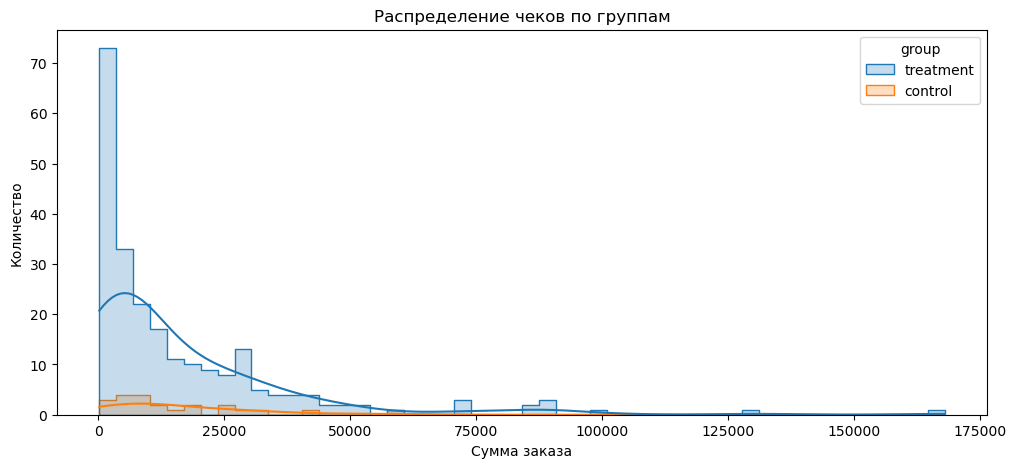

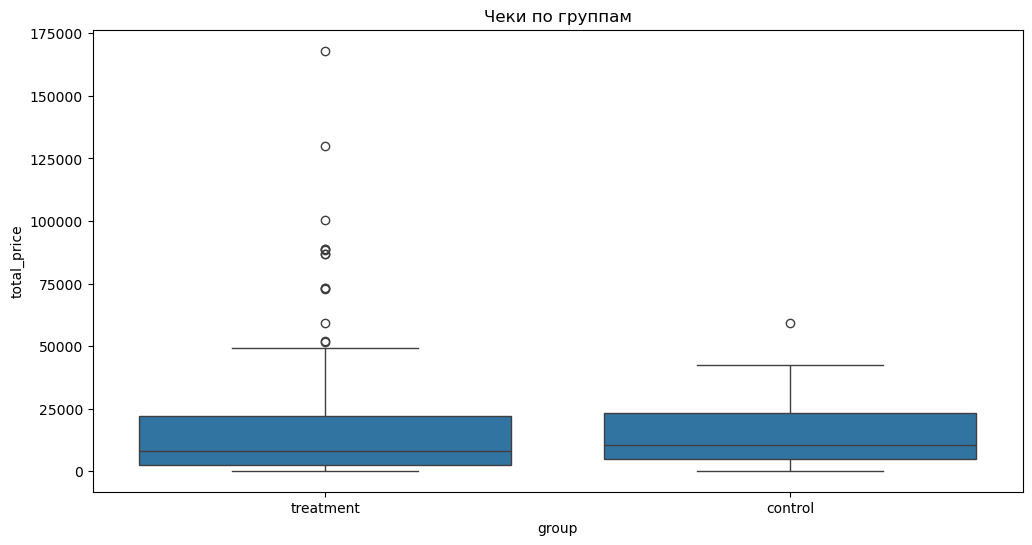

In [40]:
# Формирую индивидуальное 3-недельное окно для каждого пользователя
orders_window = (
    df_orders_ab
    .merge(df_users_final[['user_id','group','registration_date']],
           on='user_id',
           how='inner')
)

orders_window = orders_window[
    (orders_window['order_date'] >= orders_window['registration_date']) &
    (orders_window['order_date'] <= orders_window['registration_date'] + pd.Timedelta(weeks=3))
].copy()

# Формирую флаг первой покупки
first_purchase_users = orders_window['user_id'].unique()

df_users_final['first_purchase_flag'] = (
    df_users_final['user_id']
    .isin(first_purchase_users)
    .astype(int)
)

print('Доля платящих по группам:')
print(
    df_users_final.groupby('group')['first_purchase_flag']
    .mean()
)

# Основные агрегаты
metrics = df_users_final.groupby('group').agg(
    users_total=('user_id','nunique'),
    users_paying=('first_purchase_flag','sum')
).reset_index()

metrics['conversion'] = metrics['users_paying'] / metrics['users_total']

# Выручка на пользователя
revenue_per_user = (
    orders_window
    .groupby('user_id')['total_price']
    .sum()
    .reset_index()
    .merge(df_users_final[['user_id','group']], on='user_id', how='right')
)

revenue_per_user['total_price'] = revenue_per_user['total_price'].fillna(0)

group_revenue = revenue_per_user.groupby('group')['total_price'].sum()

metrics['ARPU'] = (
    group_revenue / metrics.set_index('group')['users_total']
).values

metrics['ARPPU'] = (
    group_revenue / metrics.set_index('group')['users_paying']
).values

metrics['AOV'] = (
    orders_window.groupby('group')['total_price'].sum() /
    orders_window.groupby('group')['order_id'].count()
).values

metrics['total_revenue'] = group_revenue.values

# uplift относительно контроля
control_conv = metrics.loc[metrics['group']=='control','conversion'].values[0]
metrics['conversion_uplift_%'] = (
    (metrics['conversion'] / control_conv - 1) * 100
)

display(metrics)

# Описательная статистика чеков
summary = orders_window.groupby('group')['total_price'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).round(2).reset_index()

display(summary)

# Визуальный анализ распределений
plt.figure(figsize=(12,5))

sns.histplot(
    data=orders_window,
    x='total_price',
    hue='group',
    bins=50,
    kde=True,
    element='step'
)

plt.title('Распределение чеков по группам')
plt.xlabel('Сумма заказа')
plt.ylabel('Количество')
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=orders_window, x='group', y='total_price')
plt.title('Чеки по группам')
plt.show()


В тестовой группе доля платящих пользователей составила 7,51% против 0,93% в контроле, что соответствует росту конверсии на 706%. Это привело к кратному увеличению выручки: ARPU вырос с 233 до 2 625, а общая выручка — более чем в 10 раз. При этом медианный чек (AOV) между группами сопоставим, что указывает на то, что основной эффект обеспечен ростом числа платящих пользователей, а не изменением размера заказа.

---

Теперь смотрю конверсию в покупку.

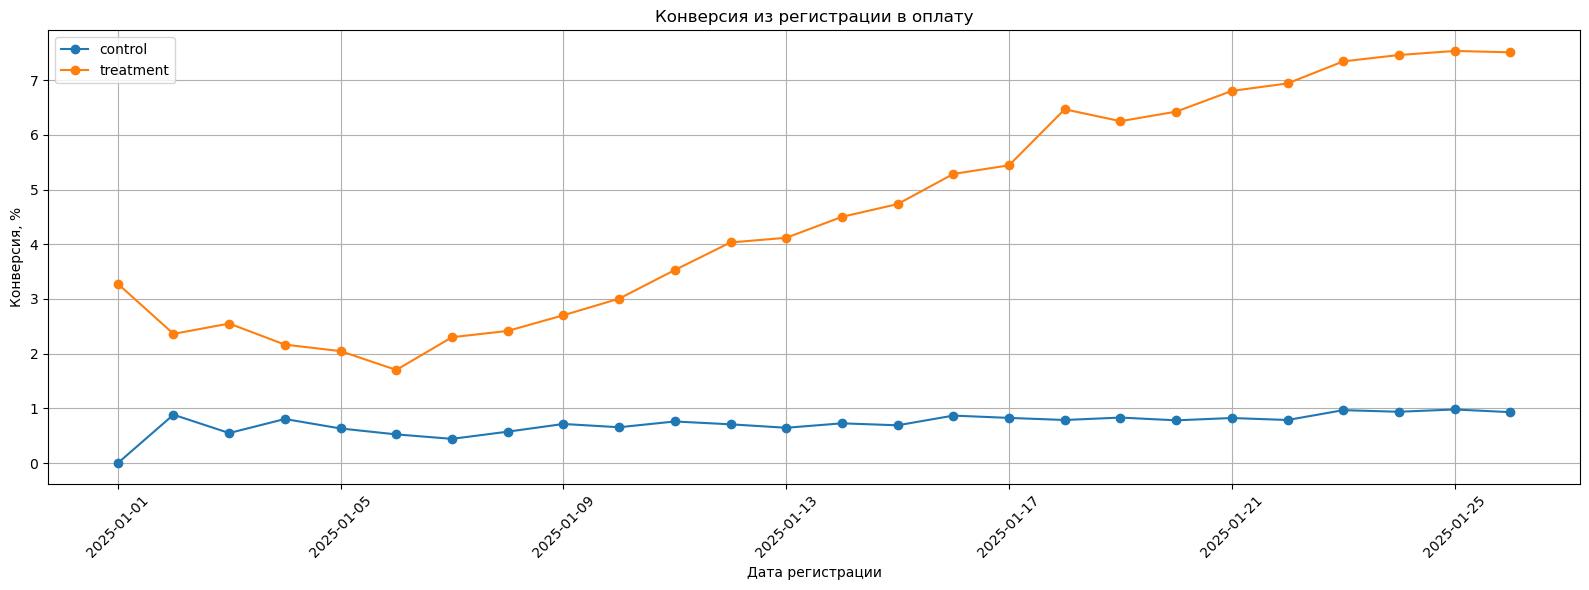

In [42]:
# Беру только нужные колонки для анализа
users = df_users_final[['user_id', 'group', 'registration_date']].copy()
orders = orders_window[['user_id', 'order_date']].copy()

# Привожу к datetime
users['registration_date'] = pd.to_datetime(users['registration_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Формирую список всех дат регистрации
date_list = users['registration_date'].dt.date.unique()
date_list.sort()

records = []

# Цикл по датам регистрации, считаем конверсию на каждый день
for current_date in date_list:
    # Беру всех пользователей, зарегистрировавшихся до текущей даты
    users_to_date = users[users['registration_date'].dt.date <= current_date]

    # Беру все оплаты этих пользователей до текущей даты
    completed_orders = orders[
        orders['user_id'].isin(users_to_date['user_id']) &
        (orders['order_date'].dt.date <= current_date)
    ]

    # Считаю общее количество пользователей по группам
    total_by_group = users_to_date.groupby('group')['user_id'].nunique().reset_index()
    total_by_group = total_by_group.rename(columns={'user_id': 'total_users'})

    # Считаю уникальных пользователей с оплатой по группам
    paid_users = completed_orders[['user_id']].drop_duplicates()
    paid_users = paid_users.merge(users[['user_id', 'group']], on='user_id', how='left')
    completed_by_group = paid_users.groupby('group')['user_id'].nunique().reset_index()
    completed_by_group = completed_by_group.rename(columns={'user_id': 'paid_users'})

    # Объединяю данные и считаю конверсию
    df_merged = pd.merge(total_by_group, completed_by_group, on='group', how='left')
    df_merged['paid_users'] = df_merged['paid_users'].fillna(0)
    df_merged['conversion'] = 100 * df_merged['paid_users'] / df_merged['total_users']
    df_merged['date'] = current_date

    records.append(df_merged)

# Собираю все результаты в один датафрейм
conversion_df = pd.concat(records, ignore_index=True)

# print(conversion_df)

# Строю график конверсии по группам
plt.figure(figsize=(16,6))

for group in conversion_df['group'].unique():
    group_data = conversion_df[conversion_df['group'] == group]
    plt.plot(group_data['date'], group_data['conversion'], marker='o', label=group)

plt.title('Конверсия из регистрации в оплату')
plt.xlabel('Дата регистрации')
plt.ylabel('Конверсия, %')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Конверсия из регистрации в оплату показывает явное преимущество тестовой группы. На старте она чуть выше 3 %, тогда как контроль держится ниже 1 %. По мере роста кумулятивного числа зарегистрированных пользователей разрыв увеличивается: к концу периода тестовая группа достигает около 7,5 %, а контроль остаётся около 0,9 %. Это говорит о значительном эффекте кампании TikTok на стимуляцию первых оплат.

---

Проведу статистический тест. Напомню гипотезу: предоставление бонуса за первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку.

In [43]:
alpha = 0.05

# --- Конверсия в первую покупку ---
display(Markdown("**Конверсия в первую покупку**"))

control_users = df_users_final[df_users_final['group']=='control']
treat_users = df_users_final[df_users_final['group']=='treatment']

control_buyers = control_users['first_purchase_flag'].sum()
control_total = len(control_users)

treat_buyers = treat_users['first_purchase_flag'].sum()
treat_total = len(treat_users)

control_rate = control_buyers / control_total
treat_rate = treat_buyers / treat_total
growth = (treat_rate / control_rate - 1) * 100 if control_rate > 0 else np.nan

z_stat, p_val = proportions_ztest([treat_buyers, control_buyers], [treat_total, control_total])

display(Markdown(f"- Контроль: {control_buyers}/{control_total} = {control_rate:.3%}"))
display(Markdown(f"- Тест:     {treat_buyers}/{treat_total} = {treat_rate:.3%}"))
display(Markdown(f"- Рост: {growth:.1f}%"))
display(Markdown(f"- Z-тест: z = {z_stat:.2f}, p = {p_val:.3f}"))
display(Markdown(f"- Вывод: {'статистически значимое улучшение' if p_val < alpha else 'различия незначимы'}"))
display(Markdown("---"))

# --- ARPU ---
display(Markdown("**ARPU (средняя выручка на пользователя)**"))

revenue_per_user = orders_window.groupby('user_id')['total_price'].sum().reset_index()
revenue_per_user = revenue_per_user.merge(df_users_final[['user_id','group']], on='user_id', how='right')
revenue_per_user['total_price'] = revenue_per_user['total_price'].fillna(0)

arpu_control = revenue_per_user[revenue_per_user['group']=='control']['total_price']
arpu_treat = revenue_per_user[revenue_per_user['group']=='treatment']['total_price']

t_stat, p_val = ttest_ind(arpu_control, arpu_treat, equal_var=False)

display(Markdown(f"- Контроль: n={len(arpu_control)}, среднее={arpu_control.mean():.2f}, медиана={arpu_control.median():.2f}"))
display(Markdown(f"- Тест:     n={len(arpu_treat)}, среднее={arpu_treat.mean():.2f}, медиана={arpu_treat.median():.2f}"))
display(Markdown(f"- t-тест: t = {t_stat:.2f}, p = {p_val:.3f}"))
display(Markdown(f"- Вывод: {'различия значимы' if p_val < alpha else 'различия незначимы'}"))
display(Markdown("---"))

# --- ARPPU ---
display(Markdown("**ARPPU (средняя выручка на платящего)**"))

arppu_control = revenue_per_user[(revenue_per_user['group']=='control') & (revenue_per_user['total_price']>0)]['total_price']
arppu_treat = revenue_per_user[(revenue_per_user['group']=='treatment') & (revenue_per_user['total_price']>0)]['total_price']

u_stat, p_val = mannwhitneyu(arppu_control, arppu_treat, alternative='two-sided')

display(Markdown(f"- Контроль: n={len(arppu_control)}, медиана={arppu_control.median():.2f}"))
display(Markdown(f"- Тест:     n={len(arppu_treat)}, медиана={arppu_treat.median():.2f}"))
display(Markdown(f"- U-тест: U = {u_stat:.2f}, p = {p_val:.3f}"))
display(Markdown(f"- Вывод: {'различия значимы' if p_val < alpha else 'различия незначимы'}"))
display(Markdown("---"))

# --- AOV ---
display(Markdown("**AOV (средний чек заказа)**"))

aov_control = orders_window[orders_window['group']=='control']['total_price']
aov_treat = orders_window[orders_window['group']=='treatment']['total_price']

u_stat, p_val = mannwhitneyu(aov_control, aov_treat, alternative='two-sided')

display(Markdown(f"- Контроль: n={len(aov_control)}, медиана={aov_control.median():.2f}"))
display(Markdown(f"- Тест:     n={len(aov_treat)}, медиана={aov_treat.median():.2f}"))
display(Markdown(f"- U-тест: U = {u_stat:.2f}, p = {p_val:.3f}"))
display(Markdown(f"- Вывод: {'различия значимы' if p_val < alpha else 'различия незначимы'}"))
display(Markdown("---"))

# --- Барьерная метрика: общая выручка по группам ---
display(Markdown("**Барьерная метрика: общая выручка по группам**"))

# Суммарная выручка каждой группы
total_revenue_by_group = orders_window.groupby('group')['total_price'].sum().reset_index()

control_total_revenue = total_revenue_by_group.loc[total_revenue_by_group['group']=='control','total_price'].values[0]
treat_total_revenue = total_revenue_by_group.loc[total_revenue_by_group['group']=='treatment','total_price'].values[0]

# Для статистики Mann-Whitney нужно передать списки значений — создаём "массивы" с одним элементом (общая выручка)
control_list = [control_total_revenue]
treat_list = [treat_total_revenue]

# Mann-Whitney
u_stat, p_val = mannwhitneyu(control_list, treat_list, alternative='two-sided')

display(Markdown(f"- Контроль: total = {control_total_revenue:.2f}"))
display(Markdown(f"- Тест:     total = {treat_total_revenue:.2f}"))
display(Markdown(f"- U-тест: U = {u_stat:.2f}, p = {p_val:.3f}"))
display(Markdown(f"- Вывод: {'различия значимы' if p_val < alpha else 'различия незначимы'}"))

**Конверсия в первую покупку**

- Контроль: 14/1503 = 0.931%

- Тест:     110/1465 = 7.509%

- Рост: 706.1%

- Z-тест: z = 8.95, p = 0.000

...

**Барьерная метрика: общая выручка по группам**

- Контроль: total = 350604.29

- Тест:     total = 3845597.03

- U-тест: U = 0.00, p = 1.000

- Вывод: различия незначимы

Основная метрика: **Конверсия в первую покупку**
Тестовая группа показывает значительное улучшение: 7.51% против 0.93% в контроле, рост +706%. Z-тест подтвердил статистическую значимость (p < 0.001). Это значит, что интервенция явно увеличила долю пользователей, совершивших первую оплату.

---

Вспомогательные метрики: 
- **ARPU** (средняя выручка на пользователя)

Средняя выручка на всех пользователей выросла с 233 ₽ до 2625 ₽, t-тест показывает значимые различия (p < 0.001). В целом пользователи теста приносят больше дохода на человека, даже с учётом большого числа неплатящих.

- **ARPPU** (средняя выручка на платящего)

Медианный доход платящих немного ниже в тесте (16551 ₽ против 22236 ₽), но U-тест показал, что различия незначимы (p = 0.556). Значит, на платящих продуктовая стратегия теста пока не влияет существенно.

- **AOV** (средний чек заказа)

Средний чек по заказу также отличается незначимо (7933 ₽ в тесте против 10428 ₽ в контроле, p = 0.334). Тест не изменил поведение по сумме отдельного заказа.

---

Барьерная метрика: **общая выручка** 

Общая выручка по сумме заказов между группами пока не подтверждает статистически значимого эффекта, несмотря на рост конверсии.

---

Общий вывод: тест сильно улучшает конверсию в первую оплату и увеличивает ARPU на всех пользователях, но это пока не отражается на средней сумме заказа и общей суммарной выручке. Тест эффективно привлекает больше покупателей, но размер медиан индивидуальных платежей уменьшился.

---

## Выводы по этапу 5

---

**Результаты теста**

Тест технически корректен:  
- Рандомизация соблюдена, контроль и тест сбалансированы по регионам, ОС и сегментам  
- Выборка очищена от пользователей с покупками до регистрации  
- Технических ошибок при разделении групп не выявлено

---


Основная метрика: **конверсия в первую покупку**  
- Контроль: 0,93 % → Тест: 7,51 %  
- Рост +706 %, Z-тест: p < 0,001 - статистически значимо  
- **Вывод**: бонус эффективно стимулирует первую покупку среди пользователей TikTok  

---


Вспомогательные метрики:  
- **ARPU** вырос с 233 ₽ до 2 625 ₽ (значимо, p < 0,001)  
- **ARPPU** и **AOV** различия незначимы (медианный чек теста чуть ниже, p > 0,3)  
- **Вывод:** тест увеличивает количество платящих пользователей, но не меняет размер среднего чека - эффект достигается за счёт привлечения новых покупателей, а не увеличения среднего платежа  

---


Барьерная метрика: **общая выручка** 
- Различия статистически незначимы (p = 1)  
- **Вывод:** несмотря на рост конверсии, суммарная выручка пока не показывает значимого эффекта  

---

**Положительные эффекты**:  
- 7-кратный рост конверсии в первую покупку
- Существенный прирост числа новых покупателей

**Отрицательные эффекты / риски**:  
- Привлечение «охотников за бонусами» с низким средним чеком  
- Снижение медианного чека - падение маржинальности  
- Неясен долгосрочный эффект на пожизненную ценность клиентов  
- Возможный отток после отмены бонуса 

---

**Рекомендации**:  
- Не масштабировать текущий формат бонуса  
- Рассмотреть альтернативы:  
  - бонус за повторные покупки для стимуляции лояльности (не в первую)
  - бонус за покупку от определённой суммы (фильтрация «бюджетных» покупателей)  
  - ступенчатый бонус (чем больше сумма, тем выше бонус)  
   
- Тест успешен с точки зрения конверсии, но экономически рискован из-за снижения маржинальности
